# Kaggle 客户流失预测 — 基线 Notebook

本 Notebook 完成：

1. 读取 `train.csv`、`test.csv`、`sample_submission.csv`
2. 基础探索性数据分析（EDA）
3. CatBoost 基线模型（5 折分层交叉验证 + OOF + 提交文件）
4. 轻量特征工程版本（与 baseline 对比）
5. 三模型融合（CatBoost + LightGBM + XGBoost）

In [2]:
# 如缺少依赖，先运行本单元格
!pip install catboost lightgbm xgboost

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
      --------------------------------------- 1.3/100.2 MB 7.4 MB/s eta 0:00:14
     - ------------------------------------- 4.5/100.2 MB 11.2 MB/s eta 0:00:09
     --- ----------------------------------- 9.7/100.2 MB 15.9 MB/s eta 0:00:06
     ----- -------------------------------- 14.7/100.2 MB 17.7 MB/s eta 0:00:05
     ------- ------------------------------ 20.4/100.2 MB 19.6 MB/s eta 0:00:05
     --------- ---------------------------- 24.9/100.2 MB 20.0 MB/s eta 0:00:04
     ---------- --------------------------- 28.6/100.2 MB 19.5 MB/s eta 0:00:04
     ------------ ------------------------- 33.6/100.2 MB 19.9 MB/s eta 0:00:04
     -------------- ----------------------- 37.5/100.2 MB 19.9 MB/s eta 0:00:04
     --------------- ---------------------- 41.4/100.2 MB 19.7 MB/s eta 0:00:03
     ----------------- -------------------- 45.6/100.2 MB 19.7 MB/

## 1. 导入库与设置路径

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 图表风格
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# 数据路径（notebook 位于 notebooks/ 目录下）
DATA_DIR = Path("../data")
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
SUBMISSION_PATH = DATA_DIR / "sample_submission.csv"

## 2. 读取数据

In [4]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SUBMISSION_PATH)

print(f"训练集大小: {train.shape}")
print(f"测试集大小: {test.shape}")
print(f"提交样例大小: {sample_submission.shape}")

训练集大小: (594194, 21)
测试集大小: (254655, 20)
提交样例大小: (254655, 2)


## 3. 数据概览

In [5]:
print("=== 训练集前 5 行 ===")
display(train.head())

print("\n=== 测试集前 5 行 ===")
display(test.head())

print("\n=== 提交样例前 5 行 ===")
display(sample_submission.head())

=== 训练集前 5 行 ===


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes



=== 测试集前 5 行 ===


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55
3,594197,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.10,6457.15
4,594198,Female,0,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.35,1233.65



=== 提交样例前 5 行 ===


,id,Churn
0,594194,0
1,594195,0
2,594196,0
3,594197,0
4,594198,0


In [6]:
print("=== 训练集字段类型 ===")
display(train.dtypes.to_frame("dtype"))

print("\n=== 训练集基本统计（数值列）===")
display(train.describe())

=== 训练集字段类型 ===


,dtype
id,int64
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object



=== 训练集基本统计（数值列）===


,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.114102,36.577258,65.866223,2494.377057
std,171529.177262,0.317936,25.061922,31.067444,2353.916710
min,0.000000,0.000000,1.000000,18.250000,18.800000
25%,148548.250000,0.000000,12.000000,29.900000,639.650000
50%,297096.500000,0.000000,35.000000,74.100000,1433.650000
75%,445644.750000,0.000000,62.000000,90.800000,4263.800000
max,594193.000000,1.000000,72.000000,118.750000,8684.800000


## 4. 缺失值检查

In [7]:
missing_train = train.isnull().sum()
missing_test = test.isnull().sum()

missing_df = pd.DataFrame({
    "train_missing": missing_train,
    "test_missing": missing_test,
})
missing_df["train_missing_pct"] = (missing_df["train_missing"] / len(train) * 100).round(2)
missing_df["test_missing_pct"] = (missing_df["test_missing"] / len(test) * 100).round(2)

display(missing_df)

if missing_df[["train_missing", "test_missing"]].sum().sum() == 0:
    print("\n训练集与测试集均无缺失值。")
else:
    print("\n存在缺失值，后续特征工程时需要处理。")

,train_missing,test_missing,train_missing_pct,test_missing_pct
Churn,0,NaN,0.0,NaN
Contract,0,0.0,0.0,0.0
Dependents,0,0.0,0.0,0.0
DeviceProtection,0,0.0,0.0,0.0
InternetService,0,0.0,0.0,0.0
MonthlyCharges,0,0.0,0.0,0.0
MultipleLines,0,0.0,0.0,0.0
OnlineBackup,0,0.0,0.0,0.0
OnlineSecurity,0,0.0,0.0,0.0
PaperlessBilling,0,0.0,0.0,0.0



训练集与测试集均无缺失值。


## 5. 目标变量分布（Churn）

流失标签计数:
Churn
No     460377
Yes    133817
Name: count, dtype: int64

流失标签占比 (%):
Churn
No     77.48
Yes    22.52
Name: proportion, dtype: float64


C:\Users\HP\AppData\Local\Temp\ipykernel_37248\3106614021.py:22: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37248\3106614021.py:22: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37248\3106614021.py:22: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37248\3106614021.py:22: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37248\3106614021.py:22: UserWarning: Glyph 21344 (\N{CJK UNIFIED IDEOGRAPH-5360}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37248\3106614021.py:22: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font

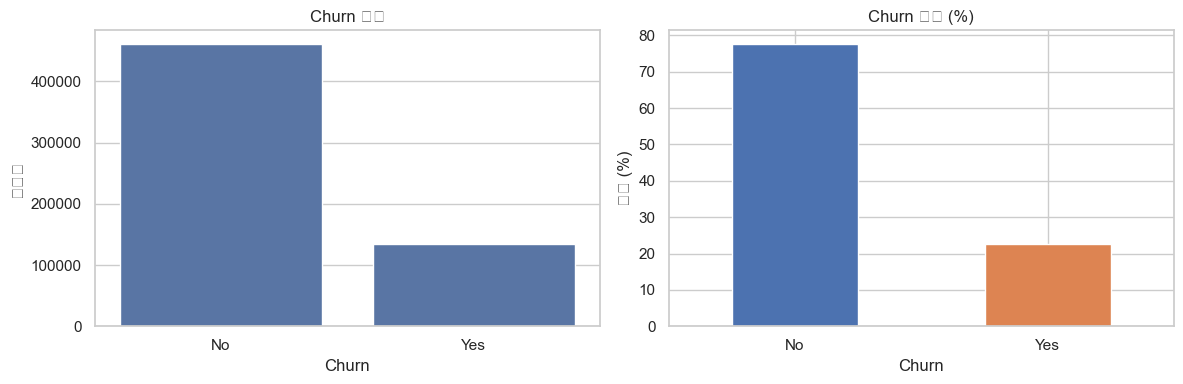

In [8]:
churn_counts = train["Churn"].value_counts()
churn_pct = train["Churn"].value_counts(normalize=True) * 100

print("流失标签计数:")
print(churn_counts)
print("\n流失标签占比 (%):")
print(churn_pct.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=train, x="Churn", ax=axes[0])
axes[0].set_title("Churn 计数")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("样本数")

churn_pct.plot(kind="bar", ax=axes[1], color=["#4C72B0", "#DD8452"])
axes[1].set_title("Churn 占比 (%)")
axes[1].set_xlabel("Churn")
axes[1].set_ylabel("占比 (%)")
axes[1].set_xticklabels(churn_pct.index, rotation=0)

plt.tight_layout()
plt.show()

## 6. 分类特征分析

In [9]:
cat_cols = train.select_dtypes(include=["object"]).columns.tolist()
cat_cols.remove("Churn")  # 目标列单独分析

print(f"分类特征共 {len(cat_cols)} 个:")
print(cat_cols)

分类特征共 15 个:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


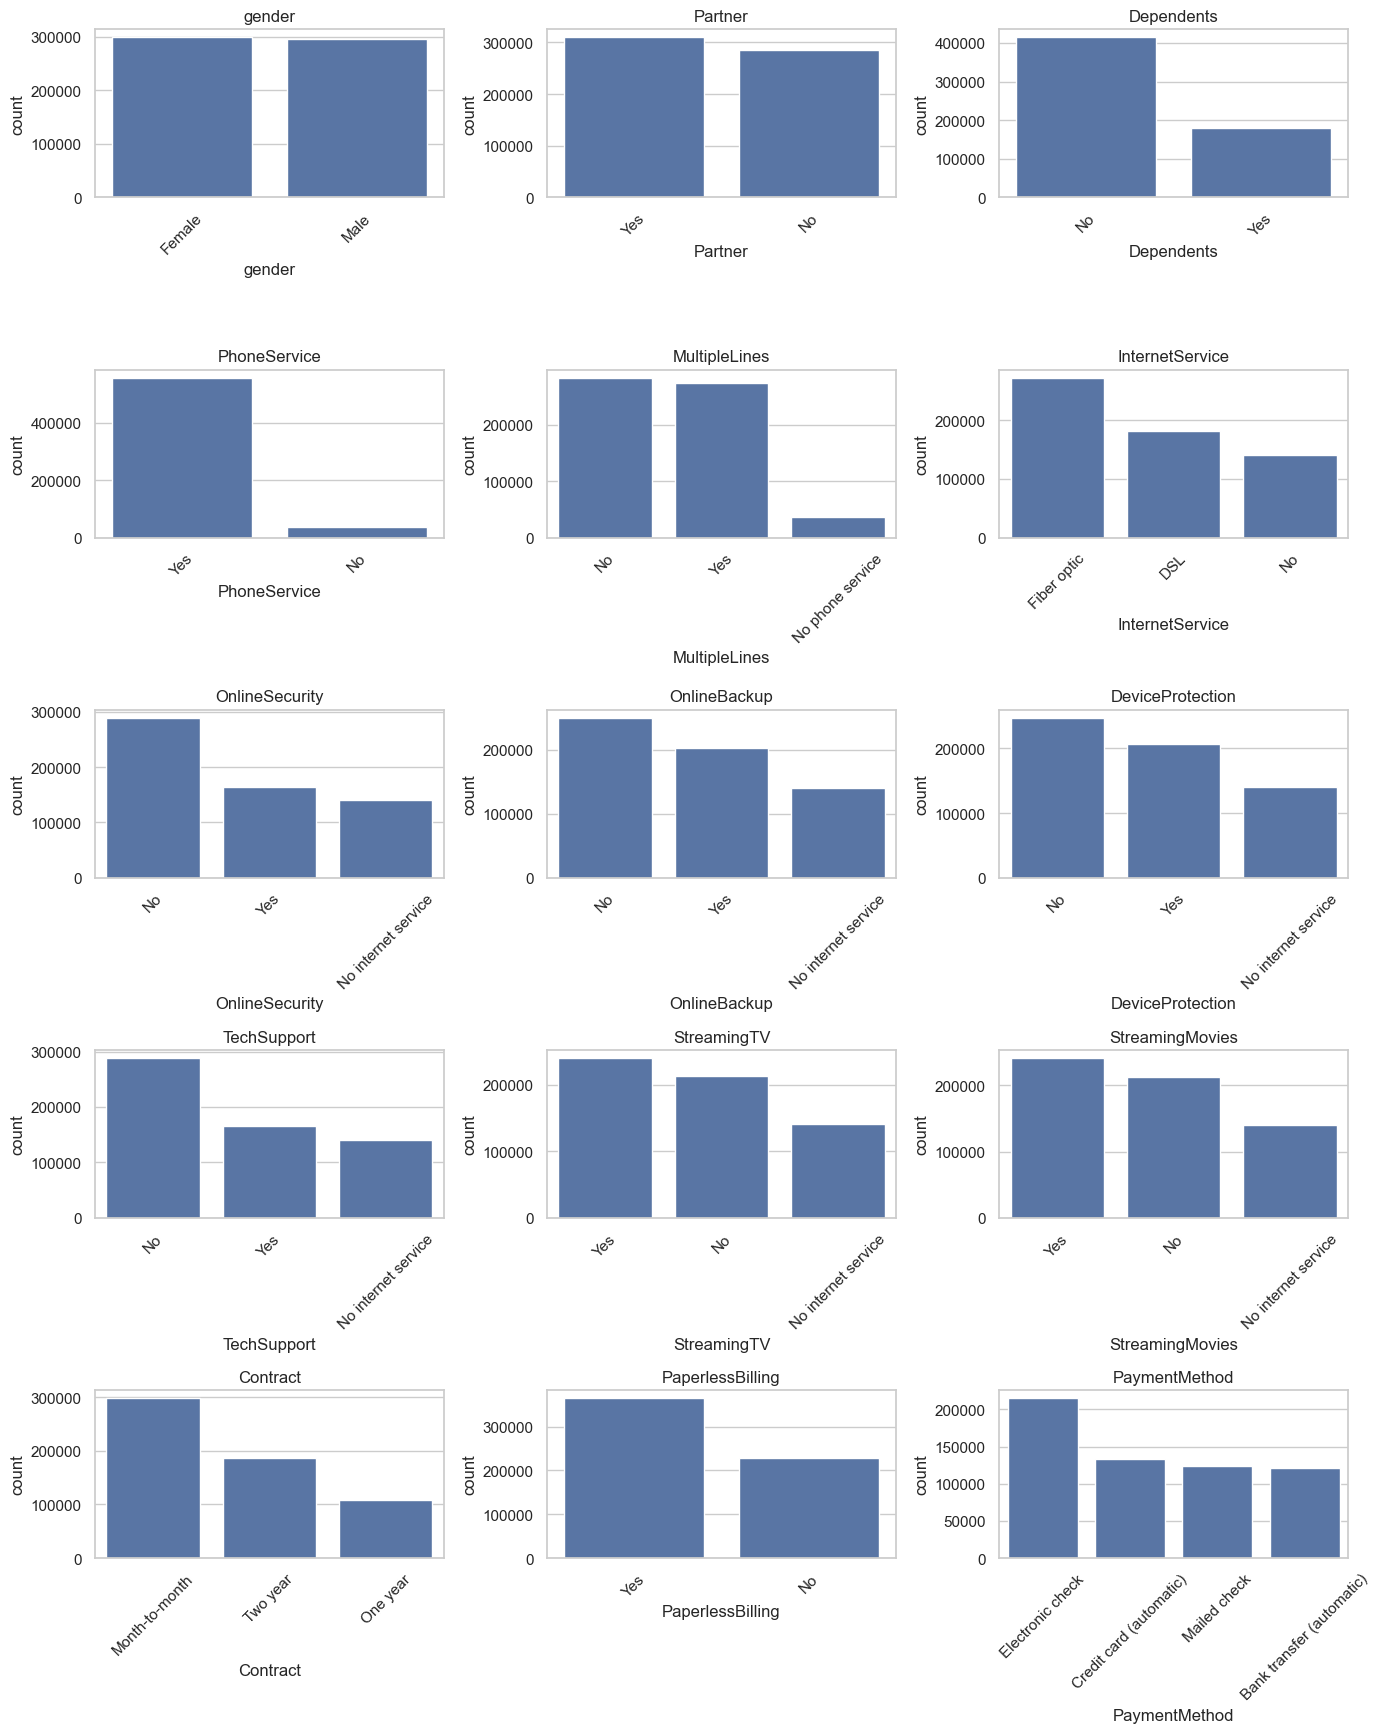

In [10]:
n_cols = 3
n_rows = int(np.ceil(len(cat_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = train[col].value_counts().index
    sns.countplot(data=train, x=col, order=order, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=45)

for j in range(len(cat_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [11]:
# 各分类特征与 Churn 的关系（流失率）
churn_rate_rows = []

for col in cat_cols:
    rate = train.groupby(col)["Churn"].apply(lambda s: (s == "Yes").mean() * 100)
    rate = rate.reset_index(name="churn_rate_pct")
    rate["feature"] = col
    churn_rate_rows.append(rate)

churn_rate_df = pd.concat(churn_rate_rows, ignore_index=True)
display(churn_rate_df.sort_values("churn_rate_pct", ascending=False).head(15))

,gender,churn_rate_pct,feature,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
39,NaN,48.905150,PaymentMethod,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Electronic check
32,NaN,42.054343,Contract,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Month-to-month,NaN,NaN
12,NaN,41.536643,InternetService,NaN,NaN,NaN,NaN,Fiber optic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,NaN,40.613319,OnlineSecurity,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,NaN,40.162040,TechSupport,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN
17,NaN,39.102618,OnlineBackup,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,NaN,38.062957,DeviceProtection,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,32.462057,Partner,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36,NaN,31.938651,PaperlessBilling,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,NaN
29,NaN,29.929916,StreamingMovies,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN


## 7. 数值特征分析

In [12]:
num_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]

print("数值特征:", num_cols)
display(train[num_cols].describe())

数值特征: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000
mean,0.114102,36.577258,65.866223,2494.377057
std,0.317936,25.061922,31.067444,2353.916710
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,12.000000,29.900000,639.650000
50%,0.000000,35.000000,74.100000,1433.650000
75%,0.000000,62.000000,90.800000,4263.800000
max,1.000000,72.000000,118.750000,8684.800000


C:\Users\HP\AppData\Local\Temp\ipykernel_37248\3845301258.py:8: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37248\3845301258.py:8: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) Arial.
  plt.tight_layout()
e:\conda\envs\nqy\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
e:\conda\envs\nqy\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


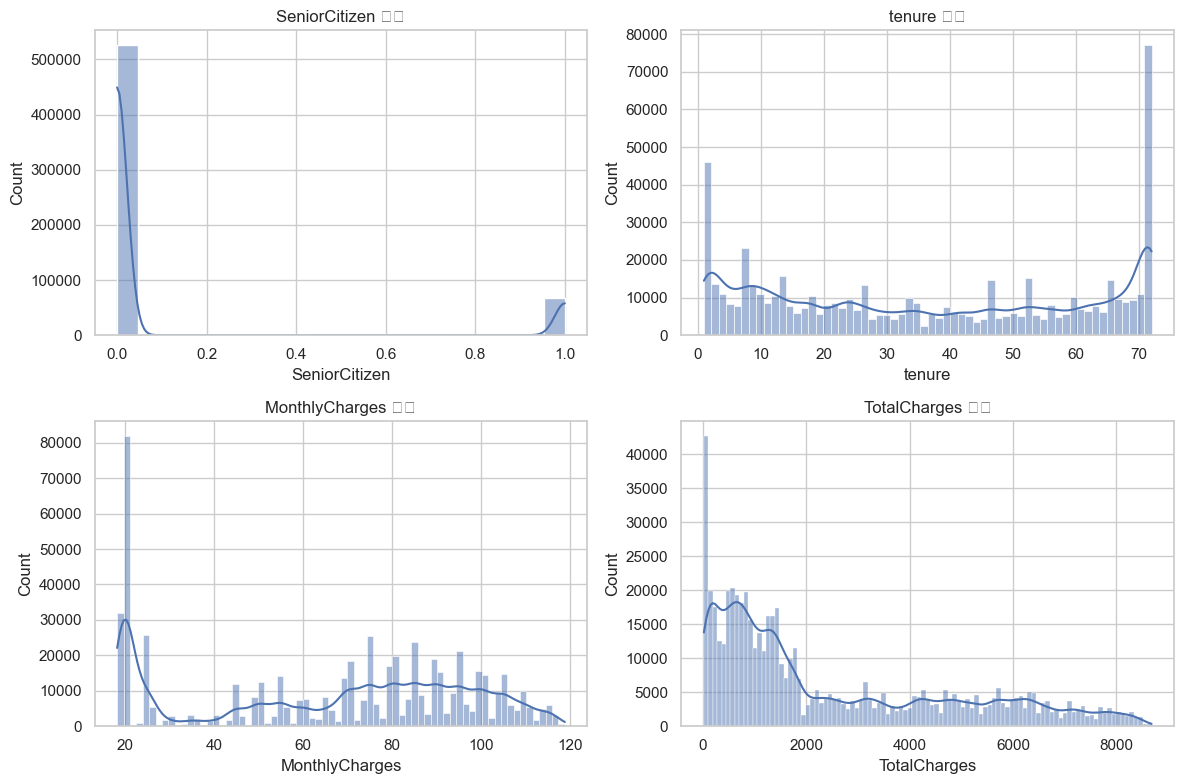

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(train[col], kde=True, ax=axes[i])
    axes[i].set_title(f"{col} 分布")

plt.tight_layout()
plt.show()

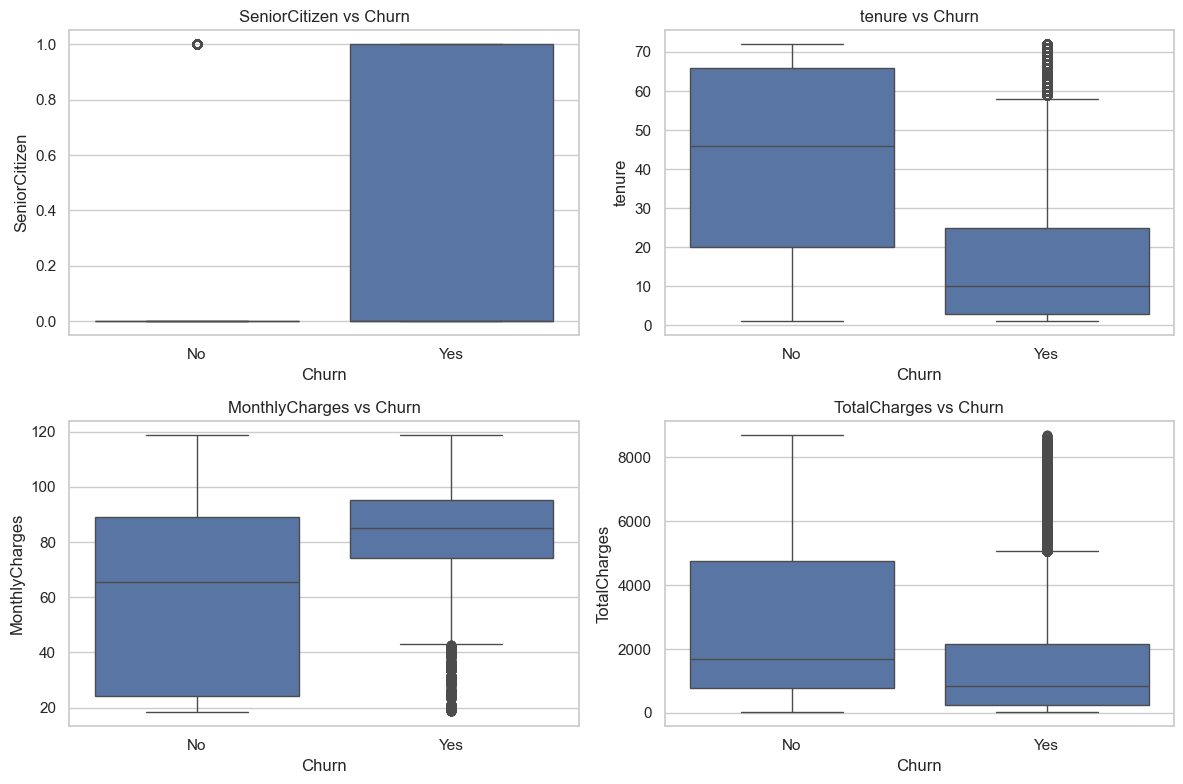

In [14]:
# 数值特征按 Churn 分组对比
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=train, x="Churn", y=col, ax=axes[i])
    axes[i].set_title(f"{col} vs Churn")

plt.tight_layout()
plt.show()

e:\conda\envs\nqy\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
e:\conda\envs\nqy\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
e:\conda\envs\nqy\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
e:\conda\envs\nqy\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
e:\conda\envs\nqy\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
e:\conda\envs\nqy\li

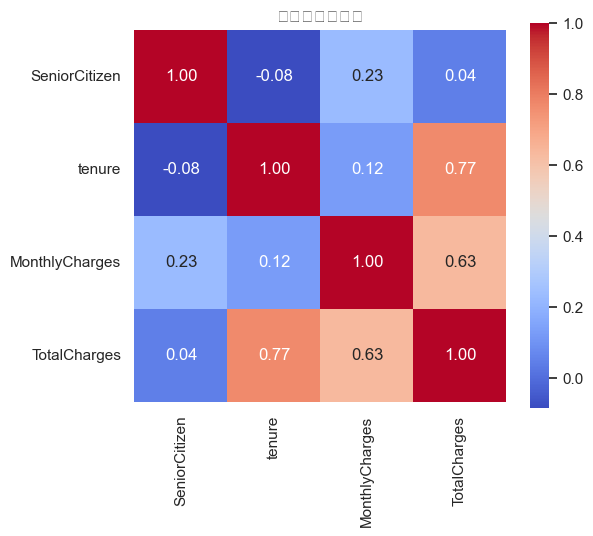

In [15]:
# 数值特征相关性（不含 id）
corr_cols = num_cols.copy()
corr_matrix = train[corr_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("数值特征相关性")
plt.show()

## 8. 训练集与测试集对比

In [16]:
train_features = set(train.columns) - {"Churn"}
test_features = set(test.columns)

print("训练集特征数（不含目标）:", len(train_features))
print("测试集特征数:", len(test_features))
print("特征是否一致:", train_features == test_features)

only_in_train = train_features - test_features
only_in_test = test_features - train_features
print("仅在训练集:", only_in_train)
print("仅在测试集:", only_in_test)

训练集特征数（不含目标）: 20
测试集特征数: 20
特征是否一致: True
仅在训练集: set()
仅在测试集: set()


In [17]:
# 检查 id 是否有重叠
overlap_ids = set(train["id"]) & set(test["id"])
print(f"训练集与测试集 id 重叠数量: {len(overlap_ids)}")
print(f"提交样例 id 数量: {sample_submission['id'].nunique()}")
print(f"测试集 id 数量: {test['id'].nunique()}")
print(f"提交样例与测试集 id 是否一致: {set(sample_submission['id']) == set(test['id'])}")

训练集与测试集 id 重叠数量: 0
提交样例 id 数量: 254655
测试集 id 数量: 254655
提交样例与测试集 id 是否一致: True


## 9. EDA 小结

通过本次 EDA，我们了解到：

- 数据规模、字段类型与缺失情况
- 目标变量 `Churn` 的类别分布（是否存在类别不平衡）
- 各分类特征的取值与流失率差异
- 数值特征的分布及其与 `Churn` 的关系
- 训练集、测试集、提交样例之间的字段与 id 对应关系

**下一步**：进入下方基线模型训练部分。

## 10. 基线模型训练（CatBoost）

本节使用 **CatBoostClassifier** 搭建第一版 baseline：

- 自动识别 id 列、目标列、数值特征、类别特征
- **StratifiedKFold** 5 折交叉验证
- 评价指标：**ROC-AUC**
- 输出每一折验证 AUC、平均 AUC 与标准差
- 生成 OOF 预测与测试集预测，并保存提交文件

In [18]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

# 输出目录
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 交叉验证设置
N_FOLDS = 5
RANDOM_STATE = 42

In [19]:
def detect_id_column(train_df, test_df, submission_df):
    """自动识别 id 列。"""
    common_id_names = ["id", "ID", "Id", "customerID", "customer_id"]

    for col in common_id_names:
        if col in train_df.columns and col in test_df.columns:
            return col

    # 提交文件第一列通常是 id
    first_col = submission_df.columns[0]
    if first_col in train_df.columns and first_col in test_df.columns:
        return first_col

    return None


def detect_target_column(train_df, test_df, submission_df):
    """自动识别目标列。"""
    # 训练集有、测试集没有的列，通常是目标列
    train_only_cols = set(train_df.columns) - set(test_df.columns)

    # 提交文件中除 id 外的列，通常是目标列名称
    id_col = detect_id_column(train_df, test_df, submission_df)
    submission_target_cols = [
        col for col in submission_df.columns if col != id_col
    ]

    # 优先取两种方法的交集
    candidates = train_only_cols & set(submission_target_cols)

    if len(candidates) == 1:
        return list(candidates)[0]

    # 若训练集仅多出一列，也视其为目标列
    if len(train_only_cols) == 1:
        return list(train_only_cols)[0]

    # 若提交文件仅有一个非 id 列，且该列在训练集中存在
    if len(submission_target_cols) == 1 and submission_target_cols[0] in train_df.columns:
        return submission_target_cols[0]

    return None


def encode_target(series):
    """将目标列编码为 0/1，便于计算 ROC-AUC。"""
    if series.dtype == "object":
        unique_vals = sorted(series.dropna().unique())
        if set(unique_vals) == {"No", "Yes"}:
            return series.map({"No": 0, "Yes": 1})
        if set(unique_vals) == {"N", "Y"}:
            return series.map({"N": 0, "Y": 1})
        # 默认将字典序较大的类别视为正类（1）
        return series.map({unique_vals[0]: 0, unique_vals[1]: 1})

    # 已经是数值时，转为 int
    return series.astype(int)


# 自动识别列
id_col = detect_id_column(train, test, sample_submission)
target_col = detect_target_column(train, test, sample_submission)

print(f"识别到的 id 列: {id_col}")
print(f"识别到的目标列: {target_col}")

if target_col is None:
    print("\n无法自动确定目标列，请手动确认。train.csv 的所有列名如下：")
    print(list(train.columns))
    raise SystemExit("请确认目标列名称后，修改代码并重新运行。")

识别到的 id 列: id
识别到的目标列: Churn


In [20]:
# 区分数值特征与类别特征（不做复杂特征工程）
feature_cols = [col for col in train.columns if col not in [id_col, target_col]]

cat_cols_model = train[feature_cols].select_dtypes(include=["object"]).columns.tolist()
num_cols_model = train[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

print(f"特征总数: {len(feature_cols)}")
print(f"数值特征 ({len(num_cols_model)}): {num_cols_model}")
print(f"类别特征 ({len(cat_cols_model)}): {cat_cols_model}")

# 准备训练数据
X = train[feature_cols].copy()
y = encode_target(train[target_col])
X_test = test[feature_cols].copy()

# CatBoost 需要知道哪些列是类别特征（传列名即可）
cat_feature_names = cat_cols_model

print("\n目标列编码后分布:")
print(y.value_counts())

特征总数: 19
数值特征 (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
类别特征 (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

目标列编码后分布:
Churn
0    460377
1    133817
Name: count, dtype: int64


In [21]:
# 初始化 OOF 预测与测试集预测
oof_preds = np.zeros(len(train))
test_preds = np.zeros(len(test))
fold_aucs = []

# 5 折分层交叉验证
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):
    print(f"\n===== Fold {fold}/{N_FOLDS} =====")

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]
    X_valid = X.iloc[valid_idx]
    y_valid = y.iloc[valid_idx]

    # 基线模型：使用默认参数，不做调参
    model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=RANDOM_STATE,
        verbose=100,
        allow_writing_files=False,
    )

    model.fit(
        X_train,
        y_train,
        cat_features=cat_feature_names,
        eval_set=(X_valid, y_valid),
        use_best_model=True,
    )

    # 验证集预测与 AUC
    valid_pred = model.predict_proba(X_valid)[:, 1]
    fold_auc = roc_auc_score(y_valid, valid_pred)
    fold_aucs.append(fold_auc)

    print(f"Fold {fold} valid AUC: {fold_auc:.6f}")

    # 保存 OOF 预测
    oof_preds[valid_idx] = valid_pred

    # 测试集预测（多折平均）
    test_preds += model.predict_proba(X_test)[:, 1] / N_FOLDS

# 汇总交叉验证结果
oof_auc = roc_auc_score(y, oof_preds)
mean_auc = np.mean(fold_aucs)
std_auc = np.std(fold_aucs)

print("\n===== 交叉验证结果 =====")
print(f"各折 AUC: {[round(a, 6) for a in fold_aucs]}")
print(f"OOF AUC: {oof_auc:.6f}")
print(f"平均 AUC: {mean_auc:.6f}")
print(f"AUC 标准差: {std_auc:.6f}")


===== Fold 1/5 =====
0:	test: 0.8723458	best: 0.8723458 (0)	total: 350ms	remaining: 2m 54s
100:	test: 0.9120055	best: 0.9120055 (100)	total: 22s	remaining: 1m 26s
200:	test: 0.9135291	best: 0.9135291 (200)	total: 44.1s	remaining: 1m 5s
300:	test: 0.9142305	best: 0.9142305 (300)	total: 1m 8s	remaining: 45.6s
400:	test: 0.9147650	best: 0.9147651 (399)	total: 1m 35s	remaining: 23.6s
499:	test: 0.9150884	best: 0.9150884 (499)	total: 2m	remaining: 0us

bestTest = 0.9150883986
bestIteration = 499

Fold 1 valid AUC: 0.915088

===== Fold 2/5 =====
0:	test: 0.8743336	best: 0.8743336 (0)	total: 157ms	remaining: 1m 18s
100:	test: 0.9133739	best: 0.9133739 (100)	total: 27.5s	remaining: 1m 48s
200:	test: 0.9145040	best: 0.9145040 (200)	total: 58.1s	remaining: 1m 26s
300:	test: 0.9152694	best: 0.9152694 (300)	total: 1m 27s	remaining: 57.7s
400:	test: 0.9158151	best: 0.9158151 (400)	total: 1m 58s	remaining: 29.1s
499:	test: 0.9161531	best: 0.9161531 (499)	total: 2m 30s	remaining: 0us

bestTest = 0.9

KeyboardInterrupt: 

In [ ]:
# 保存 OOF 预测
oof_df = pd.DataFrame({
    id_col: train[id_col],
    target_col: oof_preds,
})
oof_path = OUTPUT_DIR / "oof_catboost_baseline.csv"
oof_df.to_csv(oof_path, index=False)
print(f"OOF 文件已保存: {oof_path}")

# 按 sample_submission 格式生成提交文件
submission = sample_submission.copy()
submission[target_col] = test_preds
submission_path = OUTPUT_DIR / "submission_catboost_baseline.csv"
submission.to_csv(submission_path, index=False)
print(f"提交文件已保存: {submission_path}")

display(submission.head())

## 11. 轻量特征工程版本（Feature Engineering）

在 **baseline 对照** 基础上，增加无监督特征工程后重新训练 CatBoost：

- 数值特征：行级 `missing_count` / `num_mean` / `num_std` / `num_min` / `num_max` / `num_sum`
- 类别特征：每个类别列做 **count encoding**（在 train+test 合并后统计，避免泄露）
- 类别组合：最多 5 个组合特征
- **不做 target encoding**，避免数据泄露
- 交叉验证设置与 baseline 完全相同，便于公平对比

In [ ]:
from itertools import combinations

# 保存 baseline 结果，作为对照组
baseline_fold_aucs = fold_aucs.copy()
baseline_mean_auc = mean_auc
baseline_oof_auc = oof_auc

print("===== Baseline 对照结果（已保存）=====")
print(f"各折 AUC: {[round(a, 6) for a in baseline_fold_aucs]}")
print(f"平均 AUC: {baseline_mean_auc:.6f}")
print(f"OOF AUC: {baseline_oof_auc:.6f}")

# ------------------------------------------------------------------
# 第一步：合并 train / test 特征，统一做无监督特征工程
# ------------------------------------------------------------------
train_part = train[feature_cols].copy()
test_part = test[feature_cols].copy()
train_part["_is_train"] = 1
test_part["_is_train"] = 0

combined = pd.concat([train_part, test_part], axis=0, ignore_index=True)

# 数值列统一转为 numeric（防止个别异常值影响统计）
for col in num_cols_model:
    combined[col] = pd.to_numeric(combined[col], errors="coerce")

# 行级数值统计特征
combined["missing_count"] = combined[num_cols_model].isnull().sum(axis=1)
combined["num_mean"] = combined[num_cols_model].mean(axis=1)
combined["num_std"] = combined[num_cols_model].std(axis=1)
combined["num_min"] = combined[num_cols_model].min(axis=1)
combined["num_max"] = combined[num_cols_model].max(axis=1)
combined["num_sum"] = combined[num_cols_model].sum(axis=1)

# 每个类别特征做 count encoding（在合并后的全量数据上统计频次）
count_enc_cols = []
for col in cat_cols_model:
    enc_col = f"{col}_count_enc"
    count_map = combined[col].astype(str).value_counts()
    combined[enc_col] = combined[col].astype(str).map(count_map)
    count_enc_cols.append(enc_col)

# 最多 5 个类别组合特征（从类别列两两组合中选取前 5 个）
combo_pairs = list(combinations(cat_cols_model, 2))[:5]
combo_cols = []

for col_a, col_b in combo_pairs:
    combo_name = f"combo_{col_a}__{col_b}"
    combined[combo_name] = (
        combined[col_a].astype(str) + "__" + combined[col_b].astype(str)
    )
    combo_cols.append(combo_name)

print(f"\n新增数值统计特征: missing_count, num_mean, num_std, num_min, num_max, num_sum")
print(f"新增 count encoding 列数: {len(count_enc_cols)}")
print(f"新增类别组合特征数: {len(combo_cols)}")
print("组合特征:", combo_cols)

# ------------------------------------------------------------------
# 第二步：拆回 train / test
# ------------------------------------------------------------------
train_fe = combined[combined["_is_train"] == 1].drop(columns=["_is_train"]).reset_index(drop=True)
test_fe = combined[combined["_is_train"] == 0].drop(columns=["_is_train"]).reset_index(drop=True)

assert len(train_fe) == len(train), "特征工程后 train 行数不一致"
assert len(test_fe) == len(test), "特征工程后 test 行数不一致"

X_fe = train_fe.copy()
X_test_fe = test_fe.copy()

# CatBoost 类别特征 = 原始类别列 + 组合类别列
cat_feature_names_fe = cat_cols_model + combo_cols

print(f"\nFE 后特征总数: {X_fe.shape[1]}")
print(f"CatBoost 类别特征数: {len(cat_feature_names_fe)}")

In [ ]:
# ------------------------------------------------------------------
# 第三步：使用相同 5 折 StratifiedKFold 训练 CatBoost（特征工程版）
# 优先使用 GPU，失败则自动回退 CPU
# ------------------------------------------------------------------

# CatBoost 基础参数（与 baseline 保持一致）
fe_model_params = {
    "iterations": 500,
    "learning_rate": 0.05,
    "depth": 6,
    "loss_function": "Logloss",
    "eval_metric": "AUC",
    "random_seed": RANDOM_STATE,
    "verbose": 100,
    "allow_writing_files": False,
}

# 训练前探测 GPU 是否可用
use_gpu_fe = True
try:
    gpu_probe = CatBoostClassifier(
        iterations=10,
        task_type="GPU",
        devices="0",
        verbose=0,
        allow_writing_files=False,
    )
    probe_idx = np.arange(min(1000, len(X_fe)))
    gpu_probe.fit(
        X_fe.iloc[probe_idx],
        y.iloc[probe_idx],
        cat_features=cat_feature_names_fe,
        verbose=0,
    )
    print("当前使用 CatBoost GPU 训练")
except Exception as gpu_probe_err:
    use_gpu_fe = False
    print("GPU 训练失败，已自动切换到 CPU")
    print(f"错误原因: {gpu_probe_err}")
    print("当前使用 CatBoost CPU 训练")

oof_preds_fe = np.zeros(len(train))
test_preds_fe = np.zeros(len(test))
fold_aucs_fe = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_fe, y), start=1):
    print(f"\n===== FE Fold {fold}/{N_FOLDS} =====")

    X_tr = X_fe.iloc[train_idx]
    y_tr = y.iloc[train_idx]
    X_va = X_fe.iloc[valid_idx]
    y_va = y.iloc[valid_idx]

    # 根据设备选择参数
    current_params = fe_model_params.copy()
    if use_gpu_fe:
        current_params["task_type"] = "GPU"
        current_params["devices"] = "0"

    model_fe = CatBoostClassifier(**current_params)

    # 正式训练；若 GPU 中途失败，则回退 CPU 并重试当前折
    try:
        model_fe.fit(
            X_tr,
            y_tr,
            cat_features=cat_feature_names_fe,
            eval_set=(X_va, y_va),
            use_best_model=True,
        )
    except Exception as gpu_train_err:
        if use_gpu_fe:
            print("GPU 训练失败，已自动切换到 CPU")
            print(f"错误原因: {gpu_train_err}")
            use_gpu_fe = False
            print("当前使用 CatBoost CPU 训练")
            model_fe = CatBoostClassifier(**fe_model_params)
            model_fe.fit(
                X_tr,
                y_tr,
                cat_features=cat_feature_names_fe,
                eval_set=(X_va, y_va),
                use_best_model=True,
            )
        else:
            raise

    valid_pred_fe = model_fe.predict_proba(X_va)[:, 1]
    fold_auc_fe = roc_auc_score(y_va, valid_pred_fe)
    fold_aucs_fe.append(fold_auc_fe)

    print(f"Fold {fold} valid AUC: {fold_auc_fe:.6f}")

    oof_preds_fe[valid_idx] = valid_pred_fe
    test_preds_fe += model_fe.predict_proba(X_test_fe)[:, 1] / N_FOLDS

# 特征工程版交叉验证结果
oof_auc_fe = roc_auc_score(y, oof_preds_fe)
mean_auc_fe = np.mean(fold_aucs_fe)
std_auc_fe = np.std(fold_aucs_fe)

print("\n===== 特征工程版交叉验证结果 =====")
print(f"各折 AUC: {[round(a, 6) for a in fold_aucs_fe]}")
print(f"OOF AUC: {oof_auc_fe:.6f}")
print(f"平均 AUC: {mean_auc_fe:.6f}")
print(f"AUC 标准差: {std_auc_fe:.6f}")

# ------------------------------------------------------------------
# 第四步：与 baseline 对比
# ------------------------------------------------------------------
print("\n===== Baseline vs Feature Engineering 对比 =====")
print(f"Baseline  平均 AUC: {baseline_mean_auc:.6f} | OOF AUC: {baseline_oof_auc:.6f}")
print(f"FE 版本   平均 AUC: {mean_auc_fe:.6f} | OOF AUC: {oof_auc_fe:.6f}")
print(f"平均 AUC 提升: {mean_auc_fe - baseline_mean_auc:+.6f}")
print(f"OOF AUC 提升: {oof_auc_fe - baseline_oof_auc:+.6f}")

# 与当前正式 baseline OOF AUC 固定值对比
BASELINE_OOF_REFERENCE = 0.915442
print(f"\n相对正式 baseline OOF ({BASELINE_OOF_REFERENCE:.6f}) 提升: {oof_auc_fe - BASELINE_OOF_REFERENCE:+.6f}")

# ------------------------------------------------------------------
# 第五步：保存 OOF 与 submission
# ------------------------------------------------------------------
oof_fe_df = pd.DataFrame({
    id_col: train[id_col],
    target_col: oof_preds_fe,
})
oof_fe_path = OUTPUT_DIR / "oof_catboost_fe.csv"
oof_fe_df.to_csv(oof_fe_path, index=False)

submission_fe = sample_submission.copy()
submission_fe[target_col] = test_preds_fe
submission_fe_path = OUTPUT_DIR / "submission_catboost_fe.csv"
submission_fe.to_csv(submission_fe_path, index=False)

print(f"\nOOF 文件已保存: {oof_fe_path}")
print(f"提交文件已保存: {submission_fe_path}")

# ------------------------------------------------------------------
# 第六步：保存后立刻检查
# ------------------------------------------------------------------
print("\n===== FE 输出文件检查 =====")
oof_saved_fe = pd.read_csv(oof_fe_path)
submission_saved_fe = pd.read_csv(submission_fe_path)
sample_sub_check = pd.read_csv(SUBMISSION_PATH)

check_ok = True
check_ok &= len(oof_saved_fe) == len(train)
print(f"[{'PASS' if len(oof_saved_fe) == len(train) else 'FAIL'}] oof 行数 = train: {len(oof_saved_fe)} vs {len(train)}")

check_ok &= len(submission_saved_fe) == len(sample_sub_check)
print(f"[{'PASS' if len(submission_saved_fe) == len(sample_sub_check) else 'FAIL'}] submission 行数 = sample_submission: {len(submission_saved_fe)} vs {len(sample_sub_check)}")

cols_match = list(submission_saved_fe.columns) == list(sample_sub_check.columns)
check_ok &= cols_match
print(f"[{'PASS' if cols_match else 'FAIL'}] submission 列名与顺序一致: {list(submission_saved_fe.columns)}")

oof_range_ok = oof_saved_fe[target_col].astype(float).between(0, 1).all()
sub_range_ok = submission_saved_fe[target_col].astype(float).between(0, 1).all()
check_ok &= oof_range_ok and sub_range_ok
print(f"[{'PASS' if oof_range_ok and sub_range_ok else 'FAIL'}] 预测值在 [0, 1] 区间内")

finite_ok = (
    np.isfinite(oof_saved_fe[target_col].astype(float)).all()
    and np.isfinite(submission_saved_fe[target_col].astype(float)).all()
)
check_ok &= finite_ok
print(f"[{'PASS' if finite_ok else 'FAIL'}] 无缺失值/无穷值")

print("结论:", "全部检查通过 ✅" if check_ok else "存在未通过项 ❌")
display(submission_saved_fe.head())

## 12. 三模型融合（CatBoost + LightGBM + XGBoost）

在 **FE 特征** 上训练三个模型，再做融合提交：

- 交叉验证：与 baseline 相同的 5 折 `StratifiedKFold`
- 模型：CatBoost（优先 GPU）、LightGBM（CPU）、XGBoost（优先 GPU）
- 融合方式：简单平均、OOF AUC 加权平均、Rank Average

> 请先运行第 11 节 FE 特征构建单元格，确保 `X_fe`、`X_test_fe`、`cat_feature_names_fe` 已生成。

In [ ]:
import lightgbm as lgb
import xgboost as xgb
from scipy.stats import rankdata

# 为 LightGBM / XGBoost 准备类别型特征
X_lgb = X_fe.copy()
X_test_lgb = X_test_fe.copy()
X_xgb = X_fe.copy()
X_test_xgb = X_test_fe.copy()

for col in cat_feature_names_fe:
    X_lgb[col] = X_lgb[col].astype("category")
    X_test_lgb[col] = X_test_lgb[col].astype("category")
    X_xgb[col] = X_xgb[col].astype("category")
    X_test_xgb[col] = X_test_xgb[col].astype("category")

# 复用与 baseline 相同的交叉验证划分器
skf_blend = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# ------------------------------------------------------------------
# 1) CatBoost（优先 GPU）
# ------------------------------------------------------------------
blend_cat_params = {
    "iterations": 500,
    "learning_rate": 0.05,
    "depth": 6,
    "loss_function": "Logloss",
    "eval_metric": "AUC",
    "random_seed": RANDOM_STATE,
    "verbose": 100,
    "allow_writing_files": False,
}

use_gpu_cat = True
try:
    _probe = CatBoostClassifier(iterations=10, task_type="GPU", devices="0", verbose=0, allow_writing_files=False)
    _idx = np.arange(min(1000, len(X_fe)))
    _probe.fit(X_fe.iloc[_idx], y.iloc[_idx], cat_features=cat_feature_names_fe, verbose=0)
    print("[CatBoost] 当前使用 GPU 训练")
except Exception as e:
    use_gpu_cat = False
    print("[CatBoost] GPU 失败，已切换 CPU")
    print(f"[CatBoost] 错误原因: {e}")

oof_cat = np.zeros(len(train))
pred_cat = np.zeros(len(test))
fold_aucs_cat = []

for fold, (tr_idx, va_idx) in enumerate(skf_blend.split(X_fe, y), start=1):
    print(f"\n[CatBoost] Fold {fold}/{N_FOLDS}")
    params = blend_cat_params.copy()
    if use_gpu_cat:
        params["task_type"] = "GPU"
        params["devices"] = "0"

    model = CatBoostClassifier(**params)
    try:
        model.fit(
            X_fe.iloc[tr_idx], y.iloc[tr_idx],
            cat_features=cat_feature_names_fe,
            eval_set=(X_fe.iloc[va_idx], y.iloc[va_idx]),
            use_best_model=True,
        )
    except Exception as e:
        if use_gpu_cat:
            print("[CatBoost] GPU 失败，已切换 CPU")
            print(f"[CatBoost] 错误原因: {e}")
            use_gpu_cat = False
            model = CatBoostClassifier(**blend_cat_params)
            model.fit(
                X_fe.iloc[tr_idx], y.iloc[tr_idx],
                cat_features=cat_feature_names_fe,
                eval_set=(X_fe.iloc[va_idx], y.iloc[va_idx]),
                use_best_model=True,
            )
        else:
            raise

    vp = model.predict_proba(X_fe.iloc[va_idx])[:, 1]
    fold_aucs_cat.append(roc_auc_score(y.iloc[va_idx], vp))
    oof_cat[va_idx] = vp
    pred_cat += model.predict_proba(X_test_fe)[:, 1] / N_FOLDS
    print(f"[CatBoost] Fold {fold} AUC: {fold_aucs_cat[-1]:.6f}")

oof_auc_cat = roc_auc_score(y, oof_cat)
print(f"\n[CatBoost] 平均 AUC: {np.mean(fold_aucs_cat):.6f} | 标准差: {np.std(fold_aucs_cat):.6f} | OOF AUC: {oof_auc_cat:.6f}")

# ------------------------------------------------------------------
# 2) LightGBM（CPU，稳定优先）
# ------------------------------------------------------------------
print("\n[LightGBM] 当前使用 CPU 训练")
lgb_params = {
    "objective": "binary",
    "metric": "auc",
    "learning_rate": 0.05,
    "num_leaves": 64,
    "max_depth": 6,
    "verbosity": -1,
    "seed": RANDOM_STATE,
}

oof_lgb = np.zeros(len(train))
pred_lgb = np.zeros(len(test))
fold_aucs_lgb = []

for fold, (tr_idx, va_idx) in enumerate(skf_blend.split(X_lgb, y), start=1):
    print(f"\n[LightGBM] Fold {fold}/{N_FOLDS}")
    dtrain = lgb.Dataset(
        X_lgb.iloc[tr_idx], y.iloc[tr_idx],
        categorical_feature=cat_feature_names_fe,
    )
    dvalid = lgb.Dataset(
        X_lgb.iloc[va_idx], y.iloc[va_idx],
        categorical_feature=cat_feature_names_fe,
        reference=dtrain,
    )

    model_lgb = lgb.train(
        lgb_params,
        dtrain,
        num_boost_round=500,
        valid_sets=[dvalid],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
    )

    vp = model_lgb.predict(X_lgb.iloc[va_idx], num_iteration=model_lgb.best_iteration)
    fold_aucs_lgb.append(roc_auc_score(y.iloc[va_idx], vp))
    oof_lgb[va_idx] = vp
    pred_lgb += model_lgb.predict(X_test_lgb, num_iteration=model_lgb.best_iteration) / N_FOLDS
    print(f"[LightGBM] Fold {fold} AUC: {fold_aucs_lgb[-1]:.6f}")

oof_auc_lgb = roc_auc_score(y, oof_lgb)
print(f"\n[LightGBM] 平均 AUC: {np.mean(fold_aucs_lgb):.6f} | 标准差: {np.std(fold_aucs_lgb):.6f} | OOF AUC: {oof_auc_lgb:.6f}")

# ------------------------------------------------------------------
# 3) XGBoost（优先 GPU）
# ------------------------------------------------------------------
xgb_base_params = {
    "n_estimators": 500,
    "learning_rate": 0.05,
    "max_depth": 6,
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "random_state": RANDOM_STATE,
    "early_stopping_rounds": 50,
}

use_gpu_xgb = True
try:
    _xgb_probe = xgb.XGBClassifier(device="cuda", tree_method="hist", n_estimators=10, verbosity=0)
    _idx = np.arange(min(1000, len(X_xgb)))
    _xgb_probe.fit(X_xgb.iloc[_idx], y.iloc[_idx], verbose=False)
    print("[XGBoost] 当前使用 GPU 训练")
except Exception as e:
    use_gpu_xgb = False
    print("[XGBoost] GPU 失败，已切换 CPU")
    print(f"[XGBoost] 错误原因: {e}")

oof_xgb = np.zeros(len(train))
pred_xgb = np.zeros(len(test))
fold_aucs_xgb = []

for fold, (tr_idx, va_idx) in enumerate(skf_blend.split(X_xgb, y), start=1):
    print(f"\n[XGBoost] Fold {fold}/{N_FOLDS}")
    params = xgb_base_params.copy()
    if use_gpu_xgb:
        params["device"] = "cuda"
        params["tree_method"] = "hist"
    else:
        params.pop("device", None)

    model_xgb = xgb.XGBClassifier(**params)

    try:
        model_xgb.fit(
            X_xgb.iloc[tr_idx], y.iloc[tr_idx],
            eval_set=[(X_xgb.iloc[va_idx], y.iloc[va_idx])],
            verbose=100,
        )
    except Exception as e:
        if use_gpu_xgb:
            print("[XGBoost] GPU 失败，已切换 CPU")
            print(f"[XGBoost] 错误原因: {e}")
            use_gpu_xgb = False
            params_cpu = xgb_base_params.copy()
            model_xgb = xgb.XGBClassifier(**params_cpu)
            model_xgb.fit(
                X_xgb.iloc[tr_idx], y.iloc[tr_idx],
                eval_set=[(X_xgb.iloc[va_idx], y.iloc[va_idx])],
                verbose=100,
            )
        else:
            raise

    vp = model_xgb.predict_proba(X_xgb.iloc[va_idx])[:, 1]
    fold_aucs_xgb.append(roc_auc_score(y.iloc[va_idx], vp))
    oof_xgb[va_idx] = vp
    pred_xgb += model_xgb.predict_proba(X_test_xgb)[:, 1] / N_FOLDS
    print(f"[XGBoost] Fold {fold} AUC: {fold_aucs_xgb[-1]:.6f}")

oof_auc_xgb = roc_auc_score(y, oof_xgb)
print(f"\n[XGBoost] 平均 AUC: {np.mean(fold_aucs_xgb):.6f} | 标准差: {np.std(fold_aucs_xgb):.6f} | OOF AUC: {oof_auc_xgb:.6f}")

# ------------------------------------------------------------------
# 保存单模型 OOF 与测试集预测
# ------------------------------------------------------------------
pd.DataFrame({id_col: train[id_col], target_col: oof_cat}).to_csv(OUTPUT_DIR / "oof_catboost_blend.csv", index=False)
pd.DataFrame({id_col: train[id_col], target_col: oof_lgb}).to_csv(OUTPUT_DIR / "oof_lgbm_blend.csv", index=False)
pd.DataFrame({id_col: train[id_col], target_col: oof_xgb}).to_csv(OUTPUT_DIR / "oof_xgb_blend.csv", index=False)

pd.DataFrame({id_col: test[id_col], target_col: pred_cat}).to_csv(OUTPUT_DIR / "pred_catboost_blend.csv", index=False)
pd.DataFrame({id_col: test[id_col], target_col: pred_lgb}).to_csv(OUTPUT_DIR / "pred_lgbm_blend.csv", index=False)
pd.DataFrame({id_col: test[id_col], target_col: pred_xgb}).to_csv(OUTPUT_DIR / "pred_xgb_blend.csv", index=False)

print("\n单模型 OOF / pred 文件已保存到 outputs/")

In [ ]:
# ------------------------------------------------------------------
# 三种融合方式
# ------------------------------------------------------------------

# 1) 简单平均：三模型各 1/3
oof_blend_mean = (oof_cat + oof_lgb + oof_xgb) / 3
pred_blend_mean = (pred_cat + pred_lgb + pred_xgb) / 3
oof_auc_blend_mean = roc_auc_score(y, oof_blend_mean)

# 2) 加权平均：按各模型 OOF AUC 自动分配权重
model_oof_aucs = np.array([oof_auc_cat, oof_auc_lgb, oof_auc_xgb])
blend_weights = model_oof_aucs / model_oof_aucs.sum()
print("融合权重（按 OOF AUC）:")
print(f"  CatBoost: {blend_weights[0]:.6f}")
print(f"  LightGBM: {blend_weights[1]:.6f}")
print(f"  XGBoost:  {blend_weights[2]:.6f}")

oof_blend_weighted = (
    blend_weights[0] * oof_cat
    + blend_weights[1] * oof_lgb
    + blend_weights[2] * oof_xgb
)
pred_blend_weighted = (
    blend_weights[0] * pred_cat
    + blend_weights[1] * pred_lgb
    + blend_weights[2] * pred_xgb
)
oof_auc_blend_weighted = roc_auc_score(y, oof_blend_weighted)

# 3) Rank Average：先对每个模型预测做排名，再平均
oof_rank_cat = rankdata(oof_cat) / len(oof_cat)
oof_rank_lgb = rankdata(oof_lgb) / len(oof_lgb)
oof_rank_xgb = rankdata(oof_xgb) / len(oof_xgb)
oof_blend_rank = (oof_rank_cat + oof_rank_lgb + oof_rank_xgb) / 3
oof_auc_blend_rank = roc_auc_score(y, oof_blend_rank)

pred_rank_cat = rankdata(pred_cat) / len(pred_cat)
pred_rank_lgb = rankdata(pred_lgb) / len(pred_lgb)
pred_rank_xgb = rankdata(pred_xgb) / len(pred_xgb)
pred_blend_rank = (pred_rank_cat + pred_rank_lgb + pred_rank_xgb) / 3

print("\n===== 融合 OOF AUC =====")
print(f"blend_mean OOF AUC:     {oof_auc_blend_mean:.6f}")
print(f"blend_weighted OOF AUC: {oof_auc_blend_weighted:.6f}")
print(f"blend_rank OOF AUC:     {oof_auc_blend_rank:.6f}")

print("\n===== 单模型 vs 融合对比 =====")
print(f"CatBoost OOF: {oof_auc_cat:.6f}")
print(f"LightGBM OOF: {oof_auc_lgb:.6f}")
print(f"XGBoost OOF:  {oof_auc_xgb:.6f}")
print(f"Baseline OOF: 0.915442 | FE OOF: 0.915505")

# ------------------------------------------------------------------
# 保存融合 submission
# ------------------------------------------------------------------
sub_mean = sample_submission.copy()
sub_mean[target_col] = pred_blend_mean
sub_mean.to_csv(OUTPUT_DIR / "submission_blend_mean.csv", index=False)

sub_weighted = sample_submission.copy()
sub_weighted[target_col] = pred_blend_weighted
sub_weighted.to_csv(OUTPUT_DIR / "submission_blend_weighted.csv", index=False)

sub_rank = sample_submission.copy()
sub_rank[target_col] = pred_blend_rank
sub_rank.to_csv(OUTPUT_DIR / "submission_blend_rank.csv", index=False)

print("\n融合 submission 已保存:")
print("  outputs/submission_blend_mean.csv")
print("  outputs/submission_blend_weighted.csv")
print("  outputs/submission_blend_rank.csv")

# ------------------------------------------------------------------
# submission 检查
# ------------------------------------------------------------------
sample_sub_blend = pd.read_csv(SUBMISSION_PATH)

def check_submission(df, name):
    """检查提交文件格式与预测值分布。"""
    print(f"\n--- 检查: {name} ---")
    vals = df[target_col].astype(float)

    row_ok = len(df) == len(sample_sub_blend)
    col_ok = list(df.columns) == list(sample_sub_blend.columns)
    range_ok = vals.between(0, 1).all()
    finite_ok = np.isfinite(vals).all() and vals.notna().all()

    print(f"[{'PASS' if row_ok else 'FAIL'}] 行数一致: {len(df)} vs {len(sample_sub_blend)}")
    print(f"[{'PASS' if col_ok else 'FAIL'}] 列名顺序一致: {list(df.columns)}")
    print(f"[{'PASS' if range_ok else 'FAIL'}] 预测值在 [0, 1]")
    print(f"[{'PASS' if finite_ok else 'FAIL'}] 无缺失/无穷值")
    print(f"预测统计: min={vals.min():.6f}, max={vals.max():.6f}, mean={vals.mean():.6f}, std={vals.std():.6f}")

    return row_ok and col_ok and range_ok and finite_ok

all_ok = True
all_ok &= check_submission(sub_mean, "submission_blend_mean")
all_ok &= check_submission(sub_weighted, "submission_blend_weighted")
all_ok &= check_submission(sub_rank, "submission_blend_rank")

print("\n融合 submission 检查结论:", "全部通过 ✅" if all_ok else "存在未通过项 ❌")

## 13. Baseline 质量检查

本节对 baseline pipeline 做快速体检，确认没有常见数据泄露或提交格式错误。

> 请先运行上方训练与保存单元格，再运行下方检查代码。

In [ ]:
def check_item(name, passed, detail=""):
    """打印单项检查结果。"""
    status = "✅ PASS" if passed else "❌ FAIL"
    print(f"{status} | {name}")
    if detail:
        print(f"         {detail}")
    return passed


# 重新读取已保存文件，确保检查的是磁盘上的最终结果
oof_saved = pd.read_csv(OUTPUT_DIR / "oof_catboost_baseline.csv")
submission_saved = pd.read_csv(OUTPUT_DIR / "submission_catboost_baseline.csv")
sample_sub = pd.read_csv(SUBMISSION_PATH)

check_results = []

print("=" * 60)
print("Baseline 质量检查报告")
print("=" * 60)

# 1. id 列是否被错误加入训练
c1 = id_col not in feature_cols
check_results.append(check_item(
    "1. id 列未加入训练特征",
    c1,
    f"id 列={id_col!r}, 当前特征数={len(feature_cols)}",
))

# 2. 目标列 Churn 是否被错误加入特征
c2 = target_col not in feature_cols
check_results.append(check_item(
    "2. 目标列未加入训练特征",
    c2,
    f"目标列={target_col!r}",
))

# 3. sample_submission 的预测列是否正确使用
submission_target_cols = [c for c in sample_sub.columns if c != id_col]
c3 = (
    len(submission_target_cols) == 1
    and submission_target_cols[0] == target_col
    and target_col in submission_saved.columns
)
check_results.append(check_item(
    "3. 提交预测列名称正确",
    c3,
    f"sample_submission 目标列={submission_target_cols}, 当前目标列={target_col!r}",
))

# 4. OOF 文件行数是否与 train 一致
c4 = len(oof_saved) == len(train)
check_results.append(check_item(
    "4. OOF 行数与 train 一致",
    c4,
    f"oof={len(oof_saved)}, train={len(train)}",
))

# 5. submission 行数是否与 sample_submission 一致
c5 = len(submission_saved) == len(sample_sub)
check_results.append(check_item(
    "5. submission 行数与 sample_submission 一致",
    c5,
    f"submission={len(submission_saved)}, sample_submission={len(sample_sub)}",
))

# 6. submission 列名和顺序是否与 sample_submission 完全一致
c6 = list(submission_saved.columns) == list(sample_sub.columns)
check_results.append(check_item(
    "6. submission 列名与顺序一致",
    c6,
    f"submission 列={list(submission_saved.columns)}, 样例列={list(sample_sub.columns)}",
))

# 7. 预测值是否全部在 [0, 1]
oof_pred_vals = oof_saved[target_col].astype(float)
sub_pred_vals = submission_saved[target_col].astype(float)
c7 = (
    oof_pred_vals.between(0, 1).all()
    and sub_pred_vals.between(0, 1).all()
)
check_results.append(check_item(
    "7. 预测值均在 [0, 1] 区间",
    c7,
    f"oof 范围=[{oof_pred_vals.min():.6f}, {oof_pred_vals.max():.6f}], "
    f"submission 范围=[{sub_pred_vals.min():.6f}, {sub_pred_vals.max():.6f}]",
))

# 8. 是否存在缺失值或无穷值
c8 = (
    np.isfinite(oof_pred_vals).all()
    and np.isfinite(sub_pred_vals).all()
    and oof_pred_vals.notna().all()
    and sub_pred_vals.notna().all()
)
check_results.append(check_item(
    "8. 无缺失值/无穷值",
    c8,
    f"oof 缺失={oof_pred_vals.isna().sum()}, submission 缺失={sub_pred_vals.isna().sum()}",
))

# 9. test 预测是否为 5 折模型预测的平均值
# 核对：内存中的 test_preds 与保存文件一致（训练代码中对 5 折预测取平均）
try:
    mem_match_file = np.allclose(
        test_preds, submission_saved[target_col].values, rtol=0, atol=1e-12
    )
    c9 = mem_match_file
    detail9 = (
        f"内存 test_preds 与 submission 文件一致; "
        f"训练代码使用 {N_FOLDS} 折 predict_proba 后取平均"
    )
except NameError:
    c9 = False
    detail9 = "请先运行训练单元格，以便核对 test_preds"
check_results.append(check_item(
    "9. test 预测为 5 折平均且与提交文件一致",
    c9,
    detail9,
))

# 10. StratifiedKFold 是否使用 shuffle=True 和固定 random_state
skf_verify = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
splits_a = list(skf_verify.split(X, y))
splits_b = list(StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE).split(X, y))
c10 = all(
    np.array_equal(a, c) and np.array_equal(b, d)
    for (a, b), (c, d) in zip(splits_a, splits_b)
)
check_results.append(check_item(
    "10. StratifiedKFold 使用 shuffle=True 且 random_state 固定",
    c10,
    f"n_splits={N_FOLDS}, shuffle=True, random_state={RANDOM_STATE}",
))

# 11. 类别特征是否被 CatBoost 正确识别
c11 = (
    len(cat_feature_names) == len(cat_cols_model)
    and set(cat_feature_names) == set(cat_cols_model)
    and all(col in X.columns for col in cat_feature_names)
    and all(col in X_test.columns for col in cat_feature_names)
)
check_results.append(check_item(
    "11. CatBoost 类别特征识别正确",
    c11,
    f"类别特征数={len(cat_feature_names)}: {cat_feature_names}",
))

# 12. train/test 是否存在分开处理导致的编码不一致
encoding_issues = []
for col in cat_cols_model:
    train_cats = set(train[col].astype(str).unique())
    test_cats = set(test[col].astype(str).unique())
    unseen_in_test = test_cats - train_cats
    if unseen_in_test:
        encoding_issues.append(
            f"{col}: 测试集有 {len(unseen_in_test)} 个训练集未见类别"
        )

# CatBoost 可直接处理测试集新类别，因此这里作为提示而非 FAIL
c12 = len(encoding_issues) == 0
if c12:
    detail12 = "所有类别特征在 train/test 间取值一致"
else:
    detail12 = "；".join(encoding_issues[:3])
    if len(encoding_issues) > 3:
        detail12 += f" ... 共 {len(encoding_issues)} 列有差异"

check_results.append(check_item(
    "12. train/test 类别取值一致（CatBoost 可容忍新类别）",
    c12,
    detail12,
))

# 额外一致性：OOF 的 id 是否与 train 对齐
id_aligned = oof_saved[id_col].equals(train[id_col].reset_index(drop=True))
check_results.append(check_item(
    "附加. OOF 的 id 顺序与 train 一致",
    id_aligned,
    "用于确认 OOF 未错位",
))

print("=" * 60)
passed = sum(check_results)
total = len(check_results)
print(f"检查完成：{passed}/{total} 项通过")
if passed == total:
    print("结论：baseline pipeline 质量检查全部通过 ✅")
else:
    print("结论：存在未通过项，请根据上方 FAIL 提示排查 ❌")

## 14. 建模小结

- 使用 CatBoost 完成了第一版 **baseline** 训练
- 增加了轻量 **特征工程版本**，并与 baseline 进行 AUC 对比
- 在 FE 特征上完成 **三模型融合**（CatBoost + LightGBM + XGBoost）
- 通过 5 折分层交叉验证评估模型，指标为 ROC-AUC
- 已生成：
  - `outputs/oof_catboost_baseline.csv` / `submission_catboost_baseline.csv`
  - `outputs/oof_catboost_fe.csv` / `submission_catboost_fe.csv`
  - `outputs/submission_blend_mean.csv` / `submission_blend_weighted.csv` / `submission_blend_rank.csv`
- 可通过 **Baseline 质量检查** 确认 pipeline 是否正确

**后续可尝试**：

- 将特征工程逻辑迁移到 `src/feature.py`
- 调整各模型参数或使用 Optuna 调参
- 尝试 Stacking 等更复杂融合方式

## 15. 三模型融合 + Optuna 调参

本节追加在已有 baseline / FE / 检查代码之后，直接复用前面已经构造好的 FE 特征：`X_fe`、`X_test_fe`、`cat_feature_names_fe`、`y`、`id_col`、`target_col`。

- 统一使用 `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`
- 指标统一为 ROC-AUC
- 三个基础模型：CatBoost、LightGBM、XGBoost
- 三种基础融合：简单平均、OOF AUC 加权平均、Rank averaging
- Optuna 先使用 `n_trials=20`，如运行过慢可临时改为 `10`


In [ ]:
# 如缺少依赖，请先手动安装：
# !pip install lightgbm xgboost optuna scipy

import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import rankdata
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings("ignore")

try:
    from catboost import CatBoostClassifier
except ImportError as e:
    raise ImportError("缺少 catboost，请先运行：!pip install catboost") from e

try:
    from lightgbm import LGBMClassifier
except ImportError as e:
    raise ImportError("缺少 lightgbm，请先运行：!pip install lightgbm") from e

try:
    from xgboost import XGBClassifier
except ImportError as e:
    raise ImportError("缺少 xgboost，请先运行：!pip install xgboost") from e

try:
    import optuna
except ImportError as e:
    raise ImportError("缺少 optuna，请先运行：!pip install optuna") from e

# ------------------------------------------------------------------
# 1) 确认并复用前面已经构造好的 FE 特征
# ------------------------------------------------------------------
required_vars = [
    "X_fe", "X_test_fe", "cat_feature_names_fe", "y",
    "target_col", "id_col", "train", "test", "sample_submission",
]
missing_vars = [name for name in required_vars if name not in globals()]

if missing_vars:
    possible_keywords = [
        "fe", "feature", "train", "test", "cat", "target", "id", "y",
        "X_", "cols", "features",
    ]
    possible_vars = sorted([
        name for name in globals()
        if not name.startswith("_") and any(key.lower() in name.lower() for key in possible_keywords)
    ])
    print("未找到以下必要变量，请先运行前面的 FE 特征工程单元，或确认变量名：")
    print(missing_vars)
    print("当前 notebook 运行环境中可能相关的变量名：")
    print(possible_vars)
    raise NameError("FE 特征变量不完整，已停止，避免乱猜变量名。")

# 固定基础配置，确保所有模型验证方式一致
N_FOLDS_BLEND = 5
RANDOM_STATE_BLEND = 42
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
skf_blend = StratifiedKFold(n_splits=N_FOLDS_BLEND, shuffle=True, random_state=RANDOM_STATE_BLEND)

# 明确禁止 id 和目标列进入训练特征
for forbidden_col in [id_col, target_col, "Churn", "id"]:
    if forbidden_col in X_fe.columns:
        raise ValueError(f"发现禁止列进入训练特征: {forbidden_col}")
    if forbidden_col in X_test_fe.columns:
        raise ValueError(f"发现禁止列进入测试特征: {forbidden_col}")

# CatBoost 使用原 FE 类别特征；只保留真实存在的列，防止历史变量残留
cat_features_blend = [col for col in cat_feature_names_fe if col in X_fe.columns]

# 目标列统一编码为 0/1
if hasattr(y, "map") and y.dtype == "object":
    y_blend = y.map({"No": 0, "Yes": 1}).astype(int)
else:
    y_blend = pd.Series(y).astype(int).reset_index(drop=True)

X_fe_blend = X_fe.copy().reset_index(drop=True)
X_test_fe_blend = X_test_fe.copy().reset_index(drop=True)

print("FE 特征复用确认完成")
print(f"训练特征形状: {X_fe_blend.shape}")
print(f"测试特征形状: {X_test_fe_blend.shape}")
print(f"CatBoost 类别特征数: {len(cat_features_blend)}")
print(f"id 列: {id_col} | 目标列: {target_col}")


In [ ]:
# ------------------------------------------------------------------
# 2) 通用保存、编码、检查函数
# ------------------------------------------------------------------
def make_submission(preds, file_name):
    """按 sample_submission 的列名和顺序生成提交文件。"""
    sub = sample_submission.copy()
    sub[target_col] = np.asarray(preds, dtype=float)
    out_path = OUTPUT_DIR / file_name
    sub.to_csv(out_path, index=False)
    return out_path


def save_oof_and_pred(oof_preds, test_preds, model_key):
    """保存单模型 OOF、test pred 和 submission 文件。"""
    oof_path = OUTPUT_DIR / f"oof_{model_key}_blend.csv"
    pred_path = OUTPUT_DIR / f"pred_{model_key}_blend.csv"
    submission_path = OUTPUT_DIR / f"submission_{model_key}_blend.csv"

    pd.DataFrame({id_col: train[id_col].values, target_col: oof_preds}).to_csv(oof_path, index=False)
    pd.DataFrame({id_col: test[id_col].values, target_col: test_preds}).to_csv(pred_path, index=False)

    sub = sample_submission.copy()
    sub[target_col] = test_preds
    sub.to_csv(submission_path, index=False)

    return oof_path, pred_path, submission_path


def encode_for_tree_models(X_train_raw, X_test_raw, categorical_cols):
    """将 train/test 合并后统一编码类别列，不使用 target encoding。"""
    X_train_enc = X_train_raw.copy().reset_index(drop=True)
    X_test_enc = X_test_raw.copy().reset_index(drop=True)
    combined = pd.concat([X_train_enc, X_test_enc], axis=0, ignore_index=True)

    for col in categorical_cols:
        if col in combined.columns:
            combined[col] = combined[col].astype("category").cat.codes.astype("int32")

    # 兜底处理 object/category 列，确保 LightGBM/XGBoost 不直接接收 object
    for col in combined.select_dtypes(include=["object", "category"]).columns:
        combined[col] = combined[col].astype("category").cat.codes.astype("int32")

    # 数值列统一转为 numeric，异常值转缺失，由树模型自行处理
    for col in combined.columns:
        combined[col] = pd.to_numeric(combined[col], errors="coerce")

    X_train_enc = combined.iloc[:len(X_train_raw)].reset_index(drop=True)
    X_test_enc = combined.iloc[len(X_train_raw):].reset_index(drop=True)
    return X_train_enc, X_test_enc


def print_cv_result(model_name, fold_aucs, oof_auc):
    """统一输出 CV 指标。"""
    print(f"\n===== {model_name} CV 结果 =====")
    print(f"各折 AUC: {[round(a, 6) for a in fold_aucs]}")
    print(f"平均 AUC: {np.mean(fold_aucs):.6f}")
    print(f"标准差: {np.std(fold_aucs):.6f}")
    print(f"OOF AUC: {oof_auc:.6f}")


def rank_normalize(values):
    """将预测值做 rank 并归一化到 0 到 1。"""
    values = np.asarray(values, dtype=float)
    if len(values) <= 1:
        return np.zeros_like(values)
    return (rankdata(values, method="average") - 1) / (len(values) - 1)


# 为 LightGBM / XGBoost 准备统一编码后的 FE 特征
X_lgbm_blend, X_test_lgbm_blend = encode_for_tree_models(X_fe_blend, X_test_fe_blend, cat_features_blend)
X_xgb_blend, X_test_xgb_blend = X_lgbm_blend.copy(), X_test_lgbm_blend.copy()

print("LightGBM / XGBoost 类别编码完成")
print(f"编码后训练特征形状: {X_lgbm_blend.shape}")
print(f"object 列数量: {len(X_lgbm_blend.select_dtypes(include=['object']).columns)}")


In [ ]:
# ------------------------------------------------------------------
# 3) 训练 CatBoost / LightGBM / XGBoost 三个基础模型
# ------------------------------------------------------------------
def train_catboost_blend():
    """训练 CatBoost 5 折模型，优先 GPU，失败自动回退 CPU。"""
    base_params = {
        "iterations": 500,
        "learning_rate": 0.05,
        "depth": 6,
        "loss_function": "Logloss",
        "eval_metric": "AUC",
        "random_seed": RANDOM_STATE_BLEND,
        "verbose": False,
        "allow_writing_files": False,
    }
    gpu_params = {**base_params, "task_type": "GPU", "devices": "0"}

    use_gpu = True
    try:
        probe = CatBoostClassifier(iterations=10, task_type="GPU", devices="0", verbose=False, allow_writing_files=False)
        idx = np.arange(min(1000, len(X_fe_blend)))
        probe.fit(X_fe_blend.iloc[idx], y_blend.iloc[idx], cat_features=cat_features_blend, verbose=False)
        print("[CatBoost] GPU 探测成功，优先使用 GPU")
    except Exception as err:
        use_gpu = False
        print("[CatBoost] GPU 探测失败，自动回退 CPU")
        print(f"[CatBoost] 错误原因: {err}")

    oof = np.zeros(len(X_fe_blend))
    pred = np.zeros(len(X_test_fe_blend))
    fold_aucs = []

    for fold, (tr_idx, va_idx) in enumerate(skf_blend.split(X_fe_blend, y_blend), start=1):
        print(f"\n[CatBoost] Fold {fold}/{N_FOLDS_BLEND}")
        params = gpu_params if use_gpu else base_params
        model = CatBoostClassifier(**params)
        try:
            model.fit(
                X_fe_blend.iloc[tr_idx], y_blend.iloc[tr_idx],
                cat_features=cat_features_blend,
                eval_set=(X_fe_blend.iloc[va_idx], y_blend.iloc[va_idx]),
                use_best_model=True,
                verbose=False,
            )
        except Exception as err:
            if use_gpu:
                print("[CatBoost] GPU 正式训练失败，当前折回退 CPU 重试")
                print(f"[CatBoost] 错误原因: {err}")
                use_gpu = False
                model = CatBoostClassifier(**base_params)
                model.fit(
                    X_fe_blend.iloc[tr_idx], y_blend.iloc[tr_idx],
                    cat_features=cat_features_blend,
                    eval_set=(X_fe_blend.iloc[va_idx], y_blend.iloc[va_idx]),
                    use_best_model=True,
                    verbose=False,
                )
            else:
                raise

        va_pred = model.predict_proba(X_fe_blend.iloc[va_idx])[:, 1]
        fold_auc = roc_auc_score(y_blend.iloc[va_idx], va_pred)
        fold_aucs.append(fold_auc)
        oof[va_idx] = va_pred
        pred += model.predict_proba(X_test_fe_blend)[:, 1] / N_FOLDS_BLEND
        print(f"[CatBoost] Fold {fold} AUC: {fold_auc:.6f}")

    oof_auc = roc_auc_score(y_blend, oof)
    print_cv_result("CatBoost blend", fold_aucs, oof_auc)
    return oof, pred, fold_aucs, oof_auc


def train_lgbm_blend():
    """训练 LightGBM 5 折模型，优先 GPU，失败自动回退 CPU。"""
    base_params = {
        "objective": "binary",
        "metric": "auc",
        "learning_rate": 0.03,
        "n_estimators": 1000,
        "num_leaves": 64,
        "max_depth": -1,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_alpha": 0.1,
        "reg_lambda": 0.1,
        "random_state": RANDOM_STATE_BLEND,
        "n_jobs": -1,
        "verbosity": -1,
    }
    gpu_params = {**base_params, "device_type": "gpu"}

    use_gpu = True
    oof = np.zeros(len(X_lgbm_blend))
    pred = np.zeros(len(X_test_lgbm_blend))
    fold_aucs = []

    for fold, (tr_idx, va_idx) in enumerate(skf_blend.split(X_lgbm_blend, y_blend), start=1):
        print(f"\n[LightGBM] Fold {fold}/{N_FOLDS_BLEND}")
        params = gpu_params if use_gpu else base_params
        model = LGBMClassifier(**params)
        try:
            model.fit(
                X_lgbm_blend.iloc[tr_idx], y_blend.iloc[tr_idx],
                eval_set=[(X_lgbm_blend.iloc[va_idx], y_blend.iloc[va_idx])],
                eval_metric="auc",
            )
        except Exception as err:
            if use_gpu:
                print("[LightGBM] GPU 训练失败，当前折回退 CPU 重试")
                print(f"[LightGBM] 错误原因: {err}")
                use_gpu = False
                model = LGBMClassifier(**base_params)
                model.fit(
                    X_lgbm_blend.iloc[tr_idx], y_blend.iloc[tr_idx],
                    eval_set=[(X_lgbm_blend.iloc[va_idx], y_blend.iloc[va_idx])],
                    eval_metric="auc",
                )
            else:
                raise

        va_pred = model.predict_proba(X_lgbm_blend.iloc[va_idx])[:, 1]
        fold_auc = roc_auc_score(y_blend.iloc[va_idx], va_pred)
        fold_aucs.append(fold_auc)
        oof[va_idx] = va_pred
        pred += model.predict_proba(X_test_lgbm_blend)[:, 1] / N_FOLDS_BLEND
        print(f"[LightGBM] Fold {fold} AUC: {fold_auc:.6f}")

    oof_auc = roc_auc_score(y_blend, oof)
    print_cv_result("LightGBM blend", fold_aucs, oof_auc)
    return oof, pred, fold_aucs, oof_auc


def train_xgb_blend():
    """训练 XGBoost 5 折模型，优先 GPU，失败自动回退 CPU。"""
    base_params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "learning_rate": 0.03,
        "n_estimators": 1000,
        "max_depth": 6,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_alpha": 0.1,
        "reg_lambda": 1.0,
        "random_state": RANDOM_STATE_BLEND,
        "n_jobs": -1,
        "tree_method": "hist",
    }
    gpu_params = {**base_params, "device": "cuda"}

    use_gpu = True
    oof = np.zeros(len(X_xgb_blend))
    pred = np.zeros(len(X_test_xgb_blend))
    fold_aucs = []

    for fold, (tr_idx, va_idx) in enumerate(skf_blend.split(X_xgb_blend, y_blend), start=1):
        print(f"\n[XGBoost] Fold {fold}/{N_FOLDS_BLEND}")
        params = gpu_params if use_gpu else base_params
        model = XGBClassifier(**params)
        try:
            model.fit(
                X_xgb_blend.iloc[tr_idx], y_blend.iloc[tr_idx],
                eval_set=[(X_xgb_blend.iloc[va_idx], y_blend.iloc[va_idx])],
                verbose=False,
            )
        except Exception as err:
            if use_gpu:
                print("[XGBoost] GPU 训练失败，当前折回退 CPU 重试")
                print(f"[XGBoost] 错误原因: {err}")
                use_gpu = False
                model = XGBClassifier(**base_params)
                model.fit(
                    X_xgb_blend.iloc[tr_idx], y_blend.iloc[tr_idx],
                    eval_set=[(X_xgb_blend.iloc[va_idx], y_blend.iloc[va_idx])],
                    verbose=False,
                )
            else:
                raise

        va_pred = model.predict_proba(X_xgb_blend.iloc[va_idx])[:, 1]
        fold_auc = roc_auc_score(y_blend.iloc[va_idx], va_pred)
        fold_aucs.append(fold_auc)
        oof[va_idx] = va_pred
        pred += model.predict_proba(X_test_xgb_blend)[:, 1] / N_FOLDS_BLEND
        print(f"[XGBoost] Fold {fold} AUC: {fold_auc:.6f}")

    oof_auc = roc_auc_score(y_blend, oof)
    print_cv_result("XGBoost blend", fold_aucs, oof_auc)
    return oof, pred, fold_aucs, oof_auc


# 执行三模型训练，并保存 OOF、test pred、submission
oof_catboost_blend, pred_catboost_blend, fold_aucs_catboost_blend, oof_auc_catboost_blend = train_catboost_blend()
oof_lgbm_blend, pred_lgbm_blend, fold_aucs_lgbm_blend, oof_auc_lgbm_blend = train_lgbm_blend()
oof_xgb_blend, pred_xgb_blend, fold_aucs_xgb_blend, oof_auc_xgb_blend = train_xgb_blend()

cat_oof_path, cat_pred_path, cat_sub_path = save_oof_and_pred(oof_catboost_blend, pred_catboost_blend, "catboost")
lgbm_oof_path, lgbm_pred_path, lgbm_sub_path = save_oof_and_pred(oof_lgbm_blend, pred_lgbm_blend, "lgbm")
xgb_oof_path, xgb_pred_path, xgb_sub_path = save_oof_and_pred(oof_xgb_blend, pred_xgb_blend, "xgb")

print("\n基础模型文件已保存：")
print(cat_oof_path, cat_pred_path, cat_sub_path)
print(lgbm_oof_path, lgbm_pred_path, lgbm_sub_path)
print(xgb_oof_path, xgb_pred_path, xgb_sub_path)


In [ ]:
# ------------------------------------------------------------------
# 4) 三模型融合：简单平均 / OOF AUC 加权平均 / Rank averaging
# ------------------------------------------------------------------
base_oof_stack = np.vstack([oof_catboost_blend, oof_lgbm_blend, oof_xgb_blend])
base_pred_stack = np.vstack([pred_catboost_blend, pred_lgbm_blend, pred_xgb_blend])
base_auc_array = np.array([oof_auc_catboost_blend, oof_auc_lgbm_blend, oof_auc_xgb_blend])

# 简单平均
blend_mean_oof = base_oof_stack.mean(axis=0)
blend_mean_pred = base_pred_stack.mean(axis=0)
blend_mean_oof_auc = roc_auc_score(y_blend, blend_mean_oof)

# OOF AUC 加权平均
blend_weights = base_auc_array / base_auc_array.sum()
blend_weighted_oof = np.average(base_oof_stack, axis=0, weights=blend_weights)
blend_weighted_pred = np.average(base_pred_stack, axis=0, weights=blend_weights)
blend_weighted_oof_auc = roc_auc_score(y_blend, blend_weighted_oof)

# Rank averaging，分别对 OOF 和 test 预测做 rank 后平均
blend_rank_oof = np.vstack([rank_normalize(x) for x in base_oof_stack]).mean(axis=0)
blend_rank_pred = np.vstack([rank_normalize(x) for x in base_pred_stack]).mean(axis=0)
blend_rank_oof_auc = roc_auc_score(y_blend, blend_rank_oof)

print("===== 三模型融合结果 =====")
print(f"blend_mean OOF AUC: {blend_mean_oof_auc:.6f}")
print(f"blend_weighted OOF AUC: {blend_weighted_oof_auc:.6f}")
print(f"blend_rank OOF AUC: {blend_rank_oof_auc:.6f}")
print("OOF AUC 权重：")
print(f"  CatBoost: {blend_weights[0]:.6f}")
print(f"  LightGBM: {blend_weights[1]:.6f}")
print(f"  XGBoost:  {blend_weights[2]:.6f}")

submission_blend_mean_path = make_submission(blend_mean_pred, "submission_blend_mean.csv")
submission_blend_weighted_path = make_submission(blend_weighted_pred, "submission_blend_weighted.csv")
submission_blend_rank_path = make_submission(blend_rank_pred, "submission_blend_rank.csv")

print("融合提交文件已保存：")
print(submission_blend_mean_path)
print(submission_blend_weighted_path)
print(submission_blend_rank_path)


In [ ]:
# ------------------------------------------------------------------
# 5) Optuna：选择 OOF AUC 最高的单模型进行调参
# ------------------------------------------------------------------
single_model_scores = {
    "catboost": oof_auc_catboost_blend,
    "lgbm": oof_auc_lgbm_blend,
    "xgb": oof_auc_xgb_blend,
}
best_single_model = max(single_model_scores, key=single_model_scores.get)
print("单模型 OOF AUC：", single_model_scores)
print(f"Optuna 将调参的模型: {best_single_model}")

# 如运行过慢，可临时把 n_trials 改为 10 先测试流程
N_TRIALS_OPTUNA = 20


def objective_catboost(trial):
    """CatBoost 搜索空间，目标函数为 5 折平均 AUC。"""
    params = {
        "iterations": trial.suggest_int("iterations", 400, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
        "depth": trial.suggest_int("depth", 4, 8),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 0.0, 2.0),
        "loss_function": "Logloss",
        "eval_metric": "AUC",
        "random_seed": RANDOM_STATE_BLEND,
        "verbose": False,
        "allow_writing_files": False,
    }
    gpu_params = {**params, "task_type": "GPU", "devices": "0"}
    use_gpu = True
    fold_aucs = []

    for tr_idx, va_idx in skf_blend.split(X_fe_blend, y_blend):
        model = CatBoostClassifier(**(gpu_params if use_gpu else params))
        try:
            model.fit(
                X_fe_blend.iloc[tr_idx], y_blend.iloc[tr_idx],
                cat_features=cat_features_blend,
                eval_set=(X_fe_blend.iloc[va_idx], y_blend.iloc[va_idx]),
                use_best_model=True,
                verbose=False,
            )
        except Exception as err:
            if use_gpu:
                print("[Optuna CatBoost] GPU 失败，回退 CPU")
                print(f"[Optuna CatBoost] 错误原因: {err}")
                use_gpu = False
                model = CatBoostClassifier(**params)
                model.fit(
                    X_fe_blend.iloc[tr_idx], y_blend.iloc[tr_idx],
                    cat_features=cat_features_blend,
                    eval_set=(X_fe_blend.iloc[va_idx], y_blend.iloc[va_idx]),
                    use_best_model=True,
                    verbose=False,
                )
            else:
                raise
        pred = model.predict_proba(X_fe_blend.iloc[va_idx])[:, 1]
        fold_aucs.append(roc_auc_score(y_blend.iloc[va_idx], pred))
    return float(np.mean(fold_aucs))


def objective_lgbm(trial):
    """LightGBM 搜索空间，目标函数为 5 折平均 AUC。"""
    params = {
        "objective": "binary",
        "metric": "auc",
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 600, 1400),
        "num_leaves": trial.suggest_int("num_leaves", 31, 128),
        "max_depth": trial.suggest_int("max_depth", -1, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 2.0, log=True),
        "random_state": RANDOM_STATE_BLEND,
        "n_jobs": -1,
        "verbosity": -1,
    }
    gpu_params = {**params, "device_type": "gpu"}
    use_gpu = True
    fold_aucs = []

    for tr_idx, va_idx in skf_blend.split(X_lgbm_blend, y_blend):
        model = LGBMClassifier(**(gpu_params if use_gpu else params))
        try:
            model.fit(
                X_lgbm_blend.iloc[tr_idx], y_blend.iloc[tr_idx],
                eval_set=[(X_lgbm_blend.iloc[va_idx], y_blend.iloc[va_idx])],
                eval_metric="auc",
            )
        except Exception as err:
            if use_gpu:
                print("[Optuna LightGBM] GPU 失败，回退 CPU")
                print(f"[Optuna LightGBM] 错误原因: {err}")
                use_gpu = False
                model = LGBMClassifier(**params)
                model.fit(
                    X_lgbm_blend.iloc[tr_idx], y_blend.iloc[tr_idx],
                    eval_set=[(X_lgbm_blend.iloc[va_idx], y_blend.iloc[va_idx])],
                    eval_metric="auc",
                )
            else:
                raise
        pred = model.predict_proba(X_lgbm_blend.iloc[va_idx])[:, 1]
        fold_aucs.append(roc_auc_score(y_blend.iloc[va_idx], pred))
    return float(np.mean(fold_aucs))


def objective_xgb(trial):
    """XGBoost 搜索空间，目标函数为 5 折平均 AUC。"""
    params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 600, 1400),
        "max_depth": trial.suggest_int("max_depth", 3, 9),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 10.0),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 5.0, log=True),
        "random_state": RANDOM_STATE_BLEND,
        "n_jobs": -1,
        "tree_method": "hist",
    }
    gpu_params = {**params, "device": "cuda"}
    use_gpu = True
    fold_aucs = []

    for tr_idx, va_idx in skf_blend.split(X_xgb_blend, y_blend):
        model = XGBClassifier(**(gpu_params if use_gpu else params))
        try:
            model.fit(
                X_xgb_blend.iloc[tr_idx], y_blend.iloc[tr_idx],
                eval_set=[(X_xgb_blend.iloc[va_idx], y_blend.iloc[va_idx])],
                verbose=False,
            )
        except Exception as err:
            if use_gpu:
                print("[Optuna XGBoost] GPU 失败，回退 CPU")
                print(f"[Optuna XGBoost] 错误原因: {err}")
                use_gpu = False
                model = XGBClassifier(**params)
                model.fit(
                    X_xgb_blend.iloc[tr_idx], y_blend.iloc[tr_idx],
                    eval_set=[(X_xgb_blend.iloc[va_idx], y_blend.iloc[va_idx])],
                    verbose=False,
                )
            else:
                raise
        pred = model.predict_proba(X_xgb_blend.iloc[va_idx])[:, 1]
        fold_aucs.append(roc_auc_score(y_blend.iloc[va_idx], pred))
    return float(np.mean(fold_aucs))


objective_map = {
    "catboost": objective_catboost,
    "lgbm": objective_lgbm,
    "xgb": objective_xgb,
}

study = optuna.create_study(direction="maximize", study_name=f"{best_single_model}_fe_auc")
study.optimize(objective_map[best_single_model], n_trials=N_TRIALS_OPTUNA, show_progress_bar=True)

print("===== Optuna 调参结果 =====")
print(f"best_model: {best_single_model}")
print(f"best_value: {study.best_value:.6f}")
print("best_params:")
print(study.best_params)


In [ ]:
# ------------------------------------------------------------------
# 6) 使用 Optuna best_params 重新训练 5 折，并保存结果
# ------------------------------------------------------------------
def train_best_optuna_model(best_model_name, best_params):
    """用 Optuna 最优参数重新训练 5 折，保存 OOF 和 test 预测。"""
    oof = np.zeros(len(y_blend))
    pred = np.zeros(len(test))
    fold_aucs = []

    if best_model_name == "catboost":
        train_X, test_X = X_fe_blend, X_test_fe_blend
        params = {
            **best_params,
            "loss_function": "Logloss",
            "eval_metric": "AUC",
            "random_seed": RANDOM_STATE_BLEND,
            "verbose": False,
            "allow_writing_files": False,
        }
        gpu_params = {**params, "task_type": "GPU", "devices": "0"}
        use_gpu = True
        model_cls = CatBoostClassifier
        fit_kwargs = {"cat_features": cat_features_blend}

    elif best_model_name == "lgbm":
        train_X, test_X = X_lgbm_blend, X_test_lgbm_blend
        params = {
            **best_params,
            "objective": "binary",
            "metric": "auc",
            "random_state": RANDOM_STATE_BLEND,
            "n_jobs": -1,
            "verbosity": -1,
        }
        gpu_params = {**params, "device_type": "gpu"}
        use_gpu = True
        model_cls = LGBMClassifier
        fit_kwargs = {}

    elif best_model_name == "xgb":
        train_X, test_X = X_xgb_blend, X_test_xgb_blend
        params = {
            **best_params,
            "objective": "binary:logistic",
            "eval_metric": "auc",
            "random_state": RANDOM_STATE_BLEND,
            "n_jobs": -1,
            "tree_method": "hist",
        }
        gpu_params = {**params, "device": "cuda"}
        use_gpu = True
        model_cls = XGBClassifier
        fit_kwargs = {}
    else:
        raise ValueError(f"未知模型类型: {best_model_name}")

    for fold, (tr_idx, va_idx) in enumerate(skf_blend.split(train_X, y_blend), start=1):
        print(f"\n[Optuna Best {best_model_name}] Fold {fold}/{N_FOLDS_BLEND}")
        model = model_cls(**(gpu_params if use_gpu else params))
        try:
            if best_model_name == "catboost":
                model.fit(
                    train_X.iloc[tr_idx], y_blend.iloc[tr_idx],
                    eval_set=(train_X.iloc[va_idx], y_blend.iloc[va_idx]),
                    use_best_model=True,
                    verbose=False,
                    **fit_kwargs,
                )
            elif best_model_name == "lgbm":
                model.fit(
                    train_X.iloc[tr_idx], y_blend.iloc[tr_idx],
                    eval_set=[(train_X.iloc[va_idx], y_blend.iloc[va_idx])],
                    eval_metric="auc",
                )
            else:
                model.fit(
                    train_X.iloc[tr_idx], y_blend.iloc[tr_idx],
                    eval_set=[(train_X.iloc[va_idx], y_blend.iloc[va_idx])],
                    verbose=False,
                )
        except Exception as err:
            if use_gpu:
                print(f"[Optuna Best {best_model_name}] GPU 失败，回退 CPU")
                print(f"[Optuna Best {best_model_name}] 错误原因: {err}")
                use_gpu = False
                model = model_cls(**params)
                if best_model_name == "catboost":
                    model.fit(
                        train_X.iloc[tr_idx], y_blend.iloc[tr_idx],
                        eval_set=(train_X.iloc[va_idx], y_blend.iloc[va_idx]),
                        use_best_model=True,
                        verbose=False,
                        **fit_kwargs,
                    )
                elif best_model_name == "lgbm":
                    model.fit(
                        train_X.iloc[tr_idx], y_blend.iloc[tr_idx],
                        eval_set=[(train_X.iloc[va_idx], y_blend.iloc[va_idx])],
                        eval_metric="auc",
                    )
                else:
                    model.fit(
                        train_X.iloc[tr_idx], y_blend.iloc[tr_idx],
                        eval_set=[(train_X.iloc[va_idx], y_blend.iloc[va_idx])],
                        verbose=False,
                    )
            else:
                raise

        va_pred = model.predict_proba(train_X.iloc[va_idx])[:, 1]
        fold_auc = roc_auc_score(y_blend.iloc[va_idx], va_pred)
        fold_aucs.append(fold_auc)
        oof[va_idx] = va_pred
        pred += model.predict_proba(test_X)[:, 1] / N_FOLDS_BLEND
        print(f"[Optuna Best {best_model_name}] Fold {fold} AUC: {fold_auc:.6f}")

    oof_auc = roc_auc_score(y_blend, oof)
    print_cv_result("Optuna best", fold_aucs, oof_auc)
    return oof, pred, fold_aucs, oof_auc


oof_best_optuna, pred_best_optuna, fold_aucs_best_optuna, oof_auc_best_optuna = train_best_optuna_model(
    best_single_model,
    study.best_params,
)

pd.DataFrame({id_col: train[id_col].values, target_col: oof_best_optuna}).to_csv(OUTPUT_DIR / "oof_best_optuna.csv", index=False)
pd.DataFrame({id_col: test[id_col].values, target_col: pred_best_optuna}).to_csv(OUTPUT_DIR / "pred_best_optuna.csv", index=False)
submission_best_optuna_path = make_submission(pred_best_optuna, "submission_best_optuna.csv")
print(f"Optuna best 提交文件已保存: {submission_best_optuna_path}")


In [ ]:
# ------------------------------------------------------------------
# 7) 最终融合：三模型基础预测 + Optuna best 预测
# ------------------------------------------------------------------
final_oof_stack = np.vstack([
    oof_catboost_blend,
    oof_lgbm_blend,
    oof_xgb_blend,
    oof_best_optuna,
])
final_pred_stack = np.vstack([
    pred_catboost_blend,
    pred_lgbm_blend,
    pred_xgb_blend,
    pred_best_optuna,
])
final_auc_array = np.array([
    oof_auc_catboost_blend,
    oof_auc_lgbm_blend,
    oof_auc_xgb_blend,
    oof_auc_best_optuna,
])

# 最终简单平均
final_blend_mean_oof = final_oof_stack.mean(axis=0)
final_blend_mean_pred = final_pred_stack.mean(axis=0)
final_blend_mean_oof_auc = roc_auc_score(y_blend, final_blend_mean_oof)

# 最终 OOF AUC 加权平均
final_blend_weights = final_auc_array / final_auc_array.sum()
final_blend_weighted_oof = np.average(final_oof_stack, axis=0, weights=final_blend_weights)
final_blend_weighted_pred = np.average(final_pred_stack, axis=0, weights=final_blend_weights)
final_blend_weighted_oof_auc = roc_auc_score(y_blend, final_blend_weighted_oof)

print("===== 最终融合结果 =====")
print(f"final_blend_mean OOF AUC: {final_blend_mean_oof_auc:.6f}")
print(f"final_blend_weighted OOF AUC: {final_blend_weighted_oof_auc:.6f}")
print("最终融合权重（按 OOF AUC）：")
print(f"  CatBoost blend: {final_blend_weights[0]:.6f}")
print(f"  LightGBM blend: {final_blend_weights[1]:.6f}")
print(f"  XGBoost blend:  {final_blend_weights[2]:.6f}")
print(f"  Optuna best:    {final_blend_weights[3]:.6f}")

submission_final_blend_mean_path = make_submission(final_blend_mean_pred, "submission_final_blend_mean.csv")
submission_final_blend_weighted_path = make_submission(final_blend_weighted_pred, "submission_final_blend_weighted.csv")

print("最终融合提交文件已保存：")
print(submission_final_blend_mean_path)
print(submission_final_blend_weighted_path)


In [ ]:
# ------------------------------------------------------------------
# 8) Submission 检查 + 实验日志
# ------------------------------------------------------------------
def check_submission_file(path):
    """检查提交文件格式、缺失、无穷值和预测分布。"""
    sub = pd.read_csv(path)
    pred = sub[target_col]

    checks = {
        "行数等于 sample_submission": len(sub) == len(sample_submission),
        "列名和顺序一致": list(sub.columns) == list(sample_submission.columns),
        "预测值在 [0, 1]": pred.between(0, 1).all(),
        "不存在缺失值": not pred.isna().any(),
        "不存在无穷值": np.isfinite(pred).all(),
    }

    print(f"\n检查文件: {path}")
    for name, passed in checks.items():
        print(f"  {'PASS' if passed else 'FAIL'} | {name}")
    print(
        "  预测分布 | "
        f"min={pred.min():.6f}, max={pred.max():.6f}, "
        f"mean={pred.mean():.6f}, std={pred.std():.6f}"
    )
    return checks


submission_files_to_check = [
    cat_sub_path,
    lgbm_sub_path,
    xgb_sub_path,
    submission_blend_mean_path,
    submission_blend_weighted_path,
    submission_blend_rank_path,
    submission_best_optuna_path,
    submission_final_blend_mean_path,
    submission_final_blend_weighted_path,
]

all_submission_checks = {}
for sub_path in submission_files_to_check:
    all_submission_checks[str(sub_path)] = check_submission_file(sub_path)

# 创建或更新 experiment_log.csv
experiment_id = datetime.now().strftime("%Y%m%d_%H%M%S")
log_rows = [
    {
        "experiment_id": experiment_id,
        "model": "CatBoost blend",
        "features": "FE",
        "cv_auc": np.mean(fold_aucs_catboost_blend),
        "oof_auc": oof_auc_catboost_blend,
        "std_auc": np.std(fold_aucs_catboost_blend),
        "submission_file": str(cat_sub_path),
        "notes": "CatBoost FE 5 folds, GPU first then CPU fallback",
    },
    {
        "experiment_id": experiment_id,
        "model": "LightGBM blend",
        "features": "FE + label/category codes",
        "cv_auc": np.mean(fold_aucs_lgbm_blend),
        "oof_auc": oof_auc_lgbm_blend,
        "std_auc": np.std(fold_aucs_lgbm_blend),
        "submission_file": str(lgbm_sub_path),
        "notes": "LightGBM FE 5 folds, GPU first then CPU fallback",
    },
    {
        "experiment_id": experiment_id,
        "model": "XGBoost blend",
        "features": "FE + label/category codes",
        "cv_auc": np.mean(fold_aucs_xgb_blend),
        "oof_auc": oof_auc_xgb_blend,
        "std_auc": np.std(fold_aucs_xgb_blend),
        "submission_file": str(xgb_sub_path),
        "notes": "XGBoost FE 5 folds, CUDA first then CPU fallback",
    },
    {
        "experiment_id": experiment_id,
        "model": "blend_mean",
        "features": "FE",
        "cv_auc": np.nan,
        "oof_auc": blend_mean_oof_auc,
        "std_auc": np.nan,
        "submission_file": str(submission_blend_mean_path),
        "notes": "CatBoost + LightGBM + XGBoost simple mean",
    },
    {
        "experiment_id": experiment_id,
        "model": "blend_weighted",
        "features": "FE",
        "cv_auc": np.nan,
        "oof_auc": blend_weighted_oof_auc,
        "std_auc": np.nan,
        "submission_file": str(submission_blend_weighted_path),
        "notes": f"Weights by OOF AUC: {blend_weights.tolist()}",
    },
    {
        "experiment_id": experiment_id,
        "model": "blend_rank",
        "features": "FE",
        "cv_auc": np.nan,
        "oof_auc": blend_rank_oof_auc,
        "std_auc": np.nan,
        "submission_file": str(submission_blend_rank_path),
        "notes": "Rank averaging over three base models",
    },
    {
        "experiment_id": experiment_id,
        "model": "optuna_best",
        "features": "FE",
        "cv_auc": np.mean(fold_aucs_best_optuna),
        "oof_auc": oof_auc_best_optuna,
        "std_auc": np.std(fold_aucs_best_optuna),
        "submission_file": str(submission_best_optuna_path),
        "notes": f"Optuna tuned {best_single_model}, n_trials={N_TRIALS_OPTUNA}, best_value={study.best_value:.6f}",
    },
    {
        "experiment_id": experiment_id,
        "model": "final_blend_mean",
        "features": "FE",
        "cv_auc": np.nan,
        "oof_auc": final_blend_mean_oof_auc,
        "std_auc": np.nan,
        "submission_file": str(submission_final_blend_mean_path),
        "notes": "CatBoost + LightGBM + XGBoost + Optuna best simple mean",
    },
    {
        "experiment_id": experiment_id,
        "model": "final_blend_weighted",
        "features": "FE",
        "cv_auc": np.nan,
        "oof_auc": final_blend_weighted_oof_auc,
        "std_auc": np.nan,
        "submission_file": str(submission_final_blend_weighted_path),
        "notes": f"Weights by OOF AUC: {final_blend_weights.tolist()}",
    },
]

log_path = OUTPUT_DIR / "experiment_log.csv"
new_log_df = pd.DataFrame(log_rows)
if log_path.exists():
    old_log_df = pd.read_csv(log_path)
    log_df = pd.concat([old_log_df, new_log_df], axis=0, ignore_index=True)
else:
    log_df = new_log_df

log_df.to_csv(log_path, index=False)
print(f"\n实验日志已更新: {log_path}")
display(new_log_df)


## 16. XGBoost Optuna MultiSeed

本节复用上一节 XGBoost Optuna 的 `best_params`，只训练 XGBoost Optuna 多 seed 版本，不重新训练 CatBoost、LightGBM 或普通 XGBoost。


In [ ]:
# ------------------------------------------------------------------
# XGBoost Optuna MultiSeed：复用 FE 编码特征和 Optuna best_params
# ------------------------------------------------------------------
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier

OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BEST_OPTUNA_OOF_AUC = 0.916715
MULTISEED_SEEDS = [42, 2024, 3407, 777, 1024]
N_FOLDS_MULTISEED = 5

# 如果当前 kernel 没有 sample_submission / train / test，则从磁盘读取基础数据。
if "train" not in globals():
    train = pd.read_csv("../data/train.csv")
if "test" not in globals():
    test = pd.read_csv("../data/test.csv")
if "sample_submission" not in globals():
    sample_submission = pd.read_csv("../data/sample_submission.csv")
if "id_col" not in globals():
    id_col = "id"
if "target_col" not in globals():
    target_col = "Churn"

# 复用前面已经编码好的 XGBoost FE 特征，避免重新做 FE 或引入 target encoding。
required_xgb_vars = ["X_xgb_blend", "X_test_xgb_blend", "y_blend"]
missing_xgb_vars = [name for name in required_xgb_vars if name not in globals()]
if missing_xgb_vars:
    possible_vars = sorted([
        name for name in globals()
        if not name.startswith("_")
        and any(key in name.lower() for key in ["xgb", "fe", "blend", "train", "test", "feature", "y"])
    ])
    print("未找到 XGBoost MultiSeed 所需变量，请先运行前面的 FE 编码与三模型融合准备单元：")
    print(missing_xgb_vars)
    print("当前可能相关的变量名：")
    print(possible_vars)
    raise NameError("XGBoost FE 编码变量不完整，已停止，避免乱猜。")

# 自动查找 Optuna best_params：优先常见变量名，其次 study.best_params。
xgb_optuna_best_params = None
for _candidate_name in ["best_params", "xgb_best_params", "optuna_best_params"]:
    if _candidate_name in globals() and isinstance(globals()[_candidate_name], dict):
        xgb_optuna_best_params = globals()[_candidate_name].copy()
        print(f"使用已有变量 {_candidate_name} 作为 XGBoost Optuna best_params")
        break

if xgb_optuna_best_params is None and "study" in globals() and hasattr(study, "best_params"):
    xgb_optuna_best_params = study.best_params.copy()
    print("使用 study.best_params 作为 XGBoost Optuna best_params")

if xgb_optuna_best_params is None:
    possible_param_vars = sorted([
        name for name in globals()
        if not name.startswith("_") and any(key in name.lower() for key in ["param", "best", "study", "optuna", "xgb"])
    ])
    print("未找到 XGBoost Optuna best_params，请手动确认变量名。")
    print("当前可能相关的变量名：")
    print(possible_param_vars)
    raise NameError("未找到 best_params，已停止，避免乱猜。")

# 明确防止 id / Churn 进入训练特征。
for forbidden_col in [id_col, target_col, "id", "Churn"]:
    if forbidden_col in X_xgb_blend.columns:
        raise ValueError(f"发现禁止列进入 XGBoost 训练特征: {forbidden_col}")
    if forbidden_col in X_test_xgb_blend.columns:
        raise ValueError(f"发现禁止列进入 XGBoost 测试特征: {forbidden_col}")

X_xgb_multiseed = X_xgb_blend.copy().reset_index(drop=True)
X_test_xgb_multiseed = X_test_xgb_blend.copy().reset_index(drop=True)
y_multiseed = pd.Series(y_blend).astype(int).reset_index(drop=True)

print("XGBoost Optuna MultiSeed 准备完成")
print(f"训练特征形状: {X_xgb_multiseed.shape}")
print(f"测试特征形状: {X_test_xgb_multiseed.shape}")
print("best_params:")
print(xgb_optuna_best_params)


def check_oof_and_submission(oof_path, submission_path, oof_pred_col=target_col):
    """检查 OOF 与 submission 的行数、列顺序、取值范围和预测分布。"""
    oof_df = pd.read_csv(oof_path)
    sub_df = pd.read_csv(submission_path)
    sub_pred = sub_df[target_col]

    print(f"\n检查 OOF 文件: {oof_path}")
    print(f"  OOF 行数等于 train: {len(oof_df) == len(train)}")
    print(f"  OOF 缺失值数量: {oof_df[oof_pred_col].isna().sum()}")

    checks = {
        "submission 行数等于 sample_submission": len(sub_df) == len(sample_submission),
        "submission 列名和顺序一致": list(sub_df.columns) == list(sample_submission.columns),
        "预测值在 [0, 1]": sub_pred.between(0, 1).all(),
        "不存在缺失值": not sub_pred.isna().any(),
        "不存在无穷值": np.isfinite(sub_pred).all(),
    }
    print(f"检查 Submission 文件: {submission_path}")
    for name, passed in checks.items():
        print(f"  {'PASS' if passed else 'FAIL'} | {name}")
    print(
        "  预测分布 | "
        f"min={sub_pred.min():.6f}, max={sub_pred.max():.6f}, "
        f"mean={sub_pred.mean():.6f}, std={sub_pred.std():.6f}"
    )


def train_xgb_optuna_multiseed():
    """使用同一套 Optuna best_params，在多个 seed 下做 5 折并平均预测。"""
    all_seed_oof = []
    all_seed_test_pred = []
    seed_summaries = []

    for seed in MULTISEED_SEEDS:
        print(f"\n===== XGBoost Optuna MultiSeed | seed={seed} =====")
        skf_seed = StratifiedKFold(n_splits=N_FOLDS_MULTISEED, shuffle=True, random_state=seed)
        seed_oof = np.zeros(len(X_xgb_multiseed))
        seed_test_pred = np.zeros(len(X_test_xgb_multiseed))
        seed_fold_aucs = []
        use_gpu = True

        base_params = {
            **xgb_optuna_best_params,
            "objective": "binary:logistic",
            "eval_metric": "auc",
            "random_state": seed,
            "n_jobs": -1,
            "tree_method": "hist",
        }
        gpu_params = {**base_params, "device": "cuda"}

        for fold, (tr_idx, va_idx) in enumerate(skf_seed.split(X_xgb_multiseed, y_multiseed), start=1):
            print(f"[XGBoost Optuna MultiSeed] seed={seed} Fold {fold}/{N_FOLDS_MULTISEED}")
            model = XGBClassifier(**(gpu_params if use_gpu else base_params))
            try:
                model.fit(
                    X_xgb_multiseed.iloc[tr_idx], y_multiseed.iloc[tr_idx],
                    eval_set=[(X_xgb_multiseed.iloc[va_idx], y_multiseed.iloc[va_idx])],
                    verbose=False,
                )
            except Exception as err:
                if use_gpu:
                    print("[XGBoost Optuna MultiSeed] GPU 训练失败，当前折回退 CPU 重试")
                    print(f"[XGBoost Optuna MultiSeed] 错误原因: {err}")
                    use_gpu = False
                    model = XGBClassifier(**base_params)
                    model.fit(
                        X_xgb_multiseed.iloc[tr_idx], y_multiseed.iloc[tr_idx],
                        eval_set=[(X_xgb_multiseed.iloc[va_idx], y_multiseed.iloc[va_idx])],
                        verbose=False,
                    )
                else:
                    raise

            valid_pred = model.predict_proba(X_xgb_multiseed.iloc[va_idx])[:, 1]
            fold_auc = roc_auc_score(y_multiseed.iloc[va_idx], valid_pred)
            seed_fold_aucs.append(fold_auc)
            seed_oof[va_idx] = valid_pred
            seed_test_pred += model.predict_proba(X_test_xgb_multiseed)[:, 1] / N_FOLDS_MULTISEED
            print(f"[XGBoost Optuna MultiSeed] seed={seed} Fold {fold} AUC: {fold_auc:.6f}")

        seed_oof_auc = roc_auc_score(y_multiseed, seed_oof)
        seed_mean_auc = float(np.mean(seed_fold_aucs))
        seed_summaries.append({
            "seed": seed,
            "fold_aucs": seed_fold_aucs,
            "mean_auc": seed_mean_auc,
            "oof_auc": seed_oof_auc,
        })
        all_seed_oof.append(seed_oof)
        all_seed_test_pred.append(seed_test_pred)

        print(f"\nseed={seed} 各折 AUC: {[round(a, 6) for a in seed_fold_aucs]}")
        print(f"seed={seed} 平均 AUC: {seed_mean_auc:.6f}")
        print(f"seed={seed} OOF AUC: {seed_oof_auc:.6f}")

    multiseed_oof = np.mean(np.vstack(all_seed_oof), axis=0)
    multiseed_test_pred = np.mean(np.vstack(all_seed_test_pred), axis=0)
    multiseed_oof_auc = roc_auc_score(y_multiseed, multiseed_oof)

    print("\n===== XGBoost Optuna MultiSeed 汇总 =====")
    for row in seed_summaries:
        print(
            f"seed={row['seed']} | mean_auc={row['mean_auc']:.6f} | "
            f"oof_auc={row['oof_auc']:.6f}"
        )
    print(f"MultiSeed 平均后 OOF AUC: {multiseed_oof_auc:.6f}")
    print(f"相对 best_optuna OOF AUC={BEST_OPTUNA_OOF_AUC:.6f} 差值: {multiseed_oof_auc - BEST_OPTUNA_OOF_AUC:+.6f}")

    return multiseed_oof, multiseed_test_pred, multiseed_oof_auc, seed_summaries


oof_xgb_optuna_multiseed, pred_xgb_optuna_multiseed, oof_auc_xgb_optuna_multiseed, xgb_multiseed_summaries = train_xgb_optuna_multiseed()

oof_xgb_optuna_multiseed_path = OUTPUT_DIR / "oof_xgb_optuna_multiseed.csv"
pred_xgb_optuna_multiseed_path = OUTPUT_DIR / "pred_xgb_optuna_multiseed.csv"
submission_xgb_optuna_multiseed_path = OUTPUT_DIR / "submission_xgb_optuna_multiseed.csv"

pd.DataFrame({id_col: train[id_col].values, target_col: oof_xgb_optuna_multiseed}).to_csv(
    oof_xgb_optuna_multiseed_path, index=False
)
pd.DataFrame({id_col: test[id_col].values, target_col: pred_xgb_optuna_multiseed}).to_csv(
    pred_xgb_optuna_multiseed_path, index=False
)
submission_xgb_optuna_multiseed = sample_submission.copy()
submission_xgb_optuna_multiseed[target_col] = pred_xgb_optuna_multiseed
submission_xgb_optuna_multiseed.to_csv(submission_xgb_optuna_multiseed_path, index=False)

print("\nXGBoost Optuna MultiSeed 文件已保存：")
print(oof_xgb_optuna_multiseed_path)
print(pred_xgb_optuna_multiseed_path)
print(submission_xgb_optuna_multiseed_path)

check_oof_and_submission(oof_xgb_optuna_multiseed_path, submission_xgb_optuna_multiseed_path)


## 17. OOF 融合权重搜索

本节只读取已有 OOF 和 test prediction 文件，通过 OOF AUC 搜索非负且和为 1 的融合权重，不使用 test 标签。


In [ ]:
# ------------------------------------------------------------------
# OOF 融合权重搜索：读取已有 OOF / pred 文件，不重新训练基础模型
# ------------------------------------------------------------------
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

OUTPUT_DIR = Path("../outputs")
BEST_OPTUNA_OOF_AUC = 0.916715

if "train" not in globals():
    train = pd.read_csv("../data/train.csv")
if "test" not in globals():
    test = pd.read_csv("../data/test.csv")
if "sample_submission" not in globals():
    sample_submission = pd.read_csv("../data/sample_submission.csv")
if "id_col" not in globals():
    id_col = "id"
if "target_col" not in globals():
    target_col = "Churn"

y_for_weight_search = train[target_col].map({"No": 0, "Yes": 1}) if train[target_col].dtype == "object" else train[target_col]
y_for_weight_search = pd.Series(y_for_weight_search).astype(int).reset_index(drop=True)


def _load_prediction_file(path, base_ids, pred_col=target_col):
    """按 id 对齐读取预测文件，避免因为文件顺序变化导致错位。"""
    df = pd.read_csv(path)
    if id_col not in df.columns or pred_col not in df.columns:
        raise ValueError(f"文件缺少必要列: {path}")
    aligned = pd.DataFrame({id_col: base_ids}).merge(df[[id_col, pred_col]], on=id_col, how="left")
    if aligned[pred_col].isna().any():
        raise ValueError(f"预测文件存在无法按 id 对齐的缺失值: {path}")
    return aligned[pred_col].to_numpy(dtype=float)


# 必选模型文件。
blend_sources = [
    ("best_optuna", OUTPUT_DIR / "oof_best_optuna.csv", OUTPUT_DIR / "pred_best_optuna.csv"),
    ("xgb_blend", OUTPUT_DIR / "oof_xgb_blend.csv", OUTPUT_DIR / "pred_xgb_blend.csv"),
    ("lgbm_blend", OUTPUT_DIR / "oof_lgbm_blend.csv", OUTPUT_DIR / "pred_lgbm_blend.csv"),
    ("catboost_blend", OUTPUT_DIR / "oof_catboost_blend.csv", OUTPUT_DIR / "pred_catboost_blend.csv"),
]

# 如果 MultiSeed 已生成，则自动加入融合候选。
optional_multiseed_oof = OUTPUT_DIR / "oof_xgb_optuna_multiseed.csv"
optional_multiseed_pred = OUTPUT_DIR / "pred_xgb_optuna_multiseed.csv"
if optional_multiseed_oof.exists() and optional_multiseed_pred.exists():
    blend_sources.append(("xgb_optuna_multiseed", optional_multiseed_oof, optional_multiseed_pred))

missing_files = [
    str(path)
    for _, oof_path, pred_path in blend_sources
    for path in [oof_path, pred_path]
    if not path.exists()
]
if missing_files:
    print("以下融合所需文件不存在，请先确认：")
    print(missing_files)
    raise FileNotFoundError("OOF 权重搜索所需文件不完整。")

model_names = []
oof_arrays = []
pred_arrays = []
single_oof_aucs = {}

for model_name, oof_path, pred_path in blend_sources:
    oof_pred = _load_prediction_file(oof_path, train[id_col].values)
    test_pred = _load_prediction_file(pred_path, test[id_col].values)
    model_auc = roc_auc_score(y_for_weight_search, oof_pred)

    model_names.append(model_name)
    oof_arrays.append(oof_pred)
    pred_arrays.append(test_pred)
    single_oof_aucs[model_name] = model_auc

oof_matrix = np.vstack(oof_arrays)
pred_matrix = np.vstack(pred_arrays)

print("参与 OOF 融合权重搜索的模型：")
for name in model_names:
    print(f"  {name}: OOF AUC={single_oof_aucs[name]:.6f}")


def _normalize_weights(raw_weights):
    """将非负权重归一化到和为 1。"""
    weights = np.clip(np.asarray(raw_weights, dtype=float), 0, None)
    total = weights.sum()
    if total <= 0:
        return np.ones_like(weights) / len(weights)
    return weights / total


def _blend_auc(weights):
    """计算给定权重下的 OOF 融合 AUC。"""
    weights = _normalize_weights(weights)
    blended_oof = np.average(oof_matrix, axis=0, weights=weights)
    return roc_auc_score(y_for_weight_search, blended_oof)


# 优先使用 scipy.optimize；如果不可用，则使用 Dirichlet 随机搜索。
try:
    from scipy.optimize import minimize

    init_weights = np.ones(len(model_names)) / len(model_names)
    bounds = [(0.0, 1.0)] * len(model_names)
    constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]

    result = minimize(
        lambda w: -_blend_auc(w),
        init_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"maxiter": 1000, "ftol": 1e-12},
    )
    if not result.success:
        print(f"scipy.optimize 未完全收敛，信息: {result.message}")
    best_weights = _normalize_weights(result.x)
    search_method = "scipy.optimize SLSQP"
except Exception as err:
    print("scipy.optimize 不可用或失败，改用 Dirichlet 随机搜索")
    print(f"错误原因: {err}")
    rng = np.random.default_rng(42)
    best_weights = np.ones(len(model_names)) / len(model_names)
    best_auc = _blend_auc(best_weights)
    for _ in range(50000):
        candidate = rng.dirichlet(np.ones(len(model_names)))
        candidate_auc = _blend_auc(candidate)
        if candidate_auc > best_auc:
            best_auc = candidate_auc
            best_weights = candidate
    search_method = "Dirichlet random search"

best_weights = _normalize_weights(best_weights)
oof_oof_weight_search = np.average(oof_matrix, axis=0, weights=best_weights)
pred_oof_weight_search = np.average(pred_matrix, axis=0, weights=best_weights)
oof_auc_oof_weight_search = roc_auc_score(y_for_weight_search, oof_oof_weight_search)

print("\n===== OOF 融合权重搜索结果 =====")
print(f"搜索方法: {search_method}")
print("最优权重：")
for name, weight in zip(model_names, best_weights):
    print(f"  {name}: {weight:.8f}")
print(f"最优融合 OOF AUC: {oof_auc_oof_weight_search:.6f}")
print(f"相对 best_optuna OOF AUC={BEST_OPTUNA_OOF_AUC:.6f} 差值: {oof_auc_oof_weight_search - BEST_OPTUNA_OOF_AUC:+.6f}")

# 保存 OOF 和 submission。
oof_oof_weight_search_path = OUTPUT_DIR / "oof_oof_weight_search.csv"
submission_oof_weight_search_path = OUTPUT_DIR / "submission_oof_weight_search.csv"

pd.DataFrame({id_col: train[id_col].values, target_col: oof_oof_weight_search}).to_csv(
    oof_oof_weight_search_path, index=False
)
submission_oof_weight_search = sample_submission.copy()
submission_oof_weight_search[target_col] = pred_oof_weight_search
submission_oof_weight_search.to_csv(submission_oof_weight_search_path, index=False)

print("\nOOF 权重搜索文件已保存：")
print(oof_oof_weight_search_path)
print(submission_oof_weight_search_path)


def _check_oof_weight_outputs(oof_path, submission_path):
    """检查 OOF 权重搜索输出文件。"""
    oof_df = pd.read_csv(oof_path)
    sub_df = pd.read_csv(submission_path)
    pred = sub_df[target_col]

    print(f"\n检查 OOF 文件: {oof_path}")
    print(f"  OOF 行数等于 train: {len(oof_df) == len(train)}")
    print(f"  OOF 缺失值数量: {oof_df[target_col].isna().sum()}")
    print(f"检查 Submission 文件: {submission_path}")
    checks = {
        "submission 行数等于 sample_submission": len(sub_df) == len(sample_submission),
        "submission 列名和顺序一致": list(sub_df.columns) == list(sample_submission.columns),
        "预测值在 [0, 1]": pred.between(0, 1).all(),
        "不存在缺失值": not pred.isna().any(),
        "不存在无穷值": np.isfinite(pred).all(),
    }
    for name, passed in checks.items():
        print(f"  {'PASS' if passed else 'FAIL'} | {name}")
    print(
        "  预测分布 | "
        f"min={pred.min():.6f}, max={pred.max():.6f}, "
        f"mean={pred.mean():.6f}, std={pred.std():.6f}"
    )


_check_oof_weight_outputs(oof_oof_weight_search_path, submission_oof_weight_search_path)

# 更新实验日志，追加 MultiSeed 和 OOF Weight Search 两条记录。
experiment_log_path = OUTPUT_DIR / "experiment_log.csv"
experiment_id = datetime.now().strftime("%Y%m%d_%H%M%S")

multiseed_oof_auc_for_log = globals().get(
    "oof_auc_xgb_optuna_multiseed",
    roc_auc_score(
        y_for_weight_search,
        _load_prediction_file(OUTPUT_DIR / "oof_xgb_optuna_multiseed.csv", train[id_col].values),
    ) if (OUTPUT_DIR / "oof_xgb_optuna_multiseed.csv").exists() else np.nan,
)

new_log_rows = pd.DataFrame([
    {
        "experiment_id": experiment_id,
        "model": "XGBoost Optuna MultiSeed",
        "features": "FE",
        "cv_auc": np.nan,
        "oof_auc": multiseed_oof_auc_for_log,
        "std_auc": np.nan,
        "submission_file": str(OUTPUT_DIR / "submission_xgb_optuna_multiseed.csv"),
        "notes": "使用 Optuna best_params，多 seed 平均",
    },
    {
        "experiment_id": experiment_id,
        "model": "OOF Weight Search Blend",
        "features": "FE",
        "cv_auc": np.nan,
        "oof_auc": oof_auc_oof_weight_search,
        "std_auc": np.nan,
        "submission_file": str(submission_oof_weight_search_path),
        "notes": f"基于 OOF AUC 搜索最优融合权重，method={search_method}, weights={dict(zip(model_names, best_weights))}",
    },
])

if experiment_log_path.exists():
    old_log_df = pd.read_csv(experiment_log_path)
    experiment_log_df = pd.concat([old_log_df, new_log_rows], axis=0, ignore_index=True)
else:
    experiment_log_df = new_log_rows

experiment_log_df.to_csv(experiment_log_path, index=False)
print(f"\n实验日志已更新: {experiment_log_path}")
display(new_log_rows)


## 18. 最终极限压榨分数版本

本节只追加在 notebook 末尾，不删除、不重写前面代码；默认复用已有 FE / XGBoost 编码特征、已有 OOF / pred 文件和已有 Optuna best params。


In [ ]:
# ------------------------------------------------------------------
# 0) 最终极限压榨公共工具：复用 FE / XGBoost 编码特征，不重新做 EDA / baseline / FE
# ------------------------------------------------------------------
import ast
import re
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ID_COL_FINAL = globals().get("id_col", "id")
TARGET_COL_FINAL = globals().get("target_col", "Churn")
CURRENT_BEST_OOF_AUC = 0.916986
PREVIOUS_BEST_OPTUNA_OOF_AUC = 0.916715

# 只读取基础数据用于 id 对齐、目标评估和 submission 模板；不重新做 EDA。
if "train" not in globals():
    train = pd.read_csv("../data/train.csv")
if "test" not in globals():
    test = pd.read_csv("../data/test.csv")
if "sample_submission" not in globals():
    sample_submission = pd.read_csv("../data/sample_submission.csv")

y_final = train[TARGET_COL_FINAL].map({"No": 0, "Yes": 1}) if train[TARGET_COL_FINAL].dtype == "object" else train[TARGET_COL_FINAL]
y_final = pd.Series(y_final).astype(int).reset_index(drop=True)

def _print_possible_vars(keywords):
    """打印当前 kernel 中可能相关的变量名，方便人工确认。"""
    possible = sorted([
        name for name in globals()
        if not name.startswith("_") and any(k.lower() in name.lower() for k in keywords)
    ])
    print(possible)

def get_xgb_encoded_features():
    """复用前面已经构造好的 XGBoost 编码 FE 特征，不重新做 FE。"""
    required = ["X_xgb_blend", "X_test_xgb_blend"]
    missing = [name for name in required if name not in globals()]
    if missing:
        print("未找到 XGBoost 编码 FE 特征，请先运行前面的 FE 编码与三模型融合准备单元。缺失变量：")
        print(missing)
        print("当前可能相关的变量：")
        _print_possible_vars(["xgb", "fe", "blend", "feature", "train", "test"])
        raise NameError("缺少 XGBoost 编码 FE 特征，已停止，避免重新做 FE 或乱猜变量。")

    X_train_xgb = X_xgb_blend.copy().reset_index(drop=True)
    X_test_xgb = X_test_xgb_blend.copy().reset_index(drop=True)
    for forbidden_col in [ID_COL_FINAL, TARGET_COL_FINAL, "id", "Churn"]:
        if forbidden_col in X_train_xgb.columns:
            raise ValueError(f"发现禁止列进入训练特征: {forbidden_col}")
        if forbidden_col in X_test_xgb.columns:
            raise ValueError(f"发现禁止列进入测试特征: {forbidden_col}")
    return X_train_xgb, X_test_xgb

def extract_params_from_logs():
    """从历史训练日志中提取 Optuna best_params，作为变量不存在时的兜底方案。"""
    for log_path in [OUTPUT_DIR / "training_run.log", OUTPUT_DIR / "multiseed_weight_run.log"]:
        if not log_path.exists():
            continue
        text = log_path.read_text(encoding="utf-8", errors="ignore")
        matches = re.findall(r"best_params:\s*\n(\{[^\n]+\})", text)
        if matches:
            return ast.literal_eval(matches[-1])
    return None

def get_existing_xgb_best_params():
    """自动查找当前 XGBoost best_params；找不到则从日志提取。"""
    for name in ["xgb_optuna50_best_params", "best_params_50", "optuna50_best_params",
                 "best_params", "xgb_best_params", "optuna_best_params", "xgb_optuna_best_params"]:
        if name in globals() and isinstance(globals()[name], dict):
            print(f"使用变量 {name} 作为 XGBoost best_params")
            return globals()[name].copy()
    for study_name in ["study_50", "study"]:
        if study_name in globals() and hasattr(globals()[study_name], "best_params"):
            print(f"使用 {study_name}.best_params 作为 XGBoost best_params")
            return globals()[study_name].best_params.copy()
    params = extract_params_from_logs()
    if params is not None:
        print("从历史 Optuna 输出日志中提取 XGBoost best_params")
        return params
    print("未找到 XGBoost best_params，请手动确认变量名。当前可能相关变量：")
    _print_possible_vars(["param", "best", "study", "optuna", "xgb"])
    raise NameError("未找到 XGBoost best_params，已停止，避免乱猜。")

def make_xgb_params(params, seed=42, use_gpu=True):
    """拼接 XGBoost 固定参数；GPU 优先，失败时由训练函数回退 CPU。"""
    base = {
        **params,
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "random_state": seed,
        "n_jobs": -1,
        "tree_method": "hist",
    }
    return {**base, "device": "cuda"} if use_gpu else base

def train_xgb_cv(params, X_train_xgb, X_test_xgb, y, n_splits=5, seed=42, label="XGBoost"):
    """统一 XGBoost CV 训练函数，输出 OOF、test 预测、各折 AUC 和 OOF AUC。"""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    oof = np.zeros(len(X_train_xgb))
    pred = np.zeros(len(X_test_xgb))
    fold_aucs = []
    use_gpu = True

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train_xgb, y), start=1):
        print(f"[{label}] Fold {fold}/{n_splits}")
        model = XGBClassifier(**make_xgb_params(params, seed=seed, use_gpu=use_gpu))
        try:
            model.fit(
                X_train_xgb.iloc[tr_idx], y.iloc[tr_idx],
                eval_set=[(X_train_xgb.iloc[va_idx], y.iloc[va_idx])],
                verbose=False,
            )
        except Exception as err:
            if use_gpu:
                print(f"[{label}] GPU 训练失败，当前折回退 CPU 重试")
                print(f"[{label}] 错误原因: {err}")
                use_gpu = False
                model = XGBClassifier(**make_xgb_params(params, seed=seed, use_gpu=False))
                model.fit(
                    X_train_xgb.iloc[tr_idx], y.iloc[tr_idx],
                    eval_set=[(X_train_xgb.iloc[va_idx], y.iloc[va_idx])],
                    verbose=False,
                )
            else:
                raise

        valid_pred = model.predict_proba(X_train_xgb.iloc[va_idx])[:, 1]
        fold_auc = roc_auc_score(y.iloc[va_idx], valid_pred)
        fold_aucs.append(fold_auc)
        oof[va_idx] = valid_pred
        pred += model.predict_proba(X_test_xgb)[:, 1] / n_splits
        print(f"[{label}] Fold {fold} AUC: {fold_auc:.6f}")

    oof_auc = roc_auc_score(y, oof)
    print(f"\n===== {label} CV 结果 =====")
    print(f"各折 AUC: {[round(a, 6) for a in fold_aucs]}")
    print(f"平均 AUC: {np.mean(fold_aucs):.6f}")
    print(f"标准差: {np.std(fold_aucs):.6f}")
    print(f"OOF AUC: {oof_auc:.6f}")
    return oof, pred, fold_aucs, oof_auc

def save_oof_pred_submission(oof, pred, stem):
    """保存 OOF、test pred 和 submission。"""
    oof_path = OUTPUT_DIR / f"oof_{stem}.csv"
    pred_path = OUTPUT_DIR / f"pred_{stem}.csv"
    sub_path = OUTPUT_DIR / f"submission_{stem}.csv"
    pd.DataFrame({ID_COL_FINAL: train[ID_COL_FINAL].values, TARGET_COL_FINAL: oof}).to_csv(oof_path, index=False)
    pd.DataFrame({ID_COL_FINAL: test[ID_COL_FINAL].values, TARGET_COL_FINAL: pred}).to_csv(pred_path, index=False)
    sub = sample_submission.copy()
    sub[TARGET_COL_FINAL] = pred
    sub.to_csv(sub_path, index=False)
    print(f"已保存: {oof_path} | {pred_path} | {sub_path}")
    return oof_path, pred_path, sub_path

def load_pred_aligned(path, base_ids):
    """按 id 对齐读取 OOF / pred 文件，避免顺序错位。"""
    df = pd.read_csv(path)
    aligned = pd.DataFrame({ID_COL_FINAL: base_ids}).merge(
        df[[ID_COL_FINAL, TARGET_COL_FINAL]], on=ID_COL_FINAL, how="left"
    )
    if aligned[TARGET_COL_FINAL].isna().any():
        raise ValueError(f"文件无法按 id 完整对齐: {path}")
    return aligned[TARGET_COL_FINAL].to_numpy(dtype=float)

def check_submission(path):
    """统一检查 submission 格式和值域。"""
    sub = pd.read_csv(path)
    p = sub[TARGET_COL_FINAL]
    print(f"\n检查 submission: {path}")
    print(f"  行数等于 sample_submission: {len(sub) == len(sample_submission)}")
    print(f"  列名和顺序一致: {list(sub.columns) == list(sample_submission.columns)}")
    print(f"  预测值在 [0, 1]: {p.between(0, 1).all()}")
    print(f"  缺失值数量: {p.isna().sum()}")
    print(f"  无穷值数量: {np.isinf(p).sum()}")
    print(f"  min={p.min():.6f}, max={p.max():.6f}, mean={p.mean():.6f}, std={p.std():.6f}")

def append_experiment_log(rows):
    """追加写入 experiment_log.csv。"""
    log_path = OUTPUT_DIR / "experiment_log.csv"
    new_df = pd.DataFrame(rows)
    if log_path.exists():
        old_df = pd.read_csv(log_path)
        out_df = pd.concat([old_df, new_df], ignore_index=True)
    else:
        out_df = new_df
    out_df.to_csv(log_path, index=False)
    print(f"实验日志已更新: {log_path}")

X_xgb_final, X_test_xgb_final = get_xgb_encoded_features()
base_xgb_best_params_final = get_existing_xgb_best_params()
print("最终极限压榨公共准备完成")
print(f"X_train: {X_xgb_final.shape}, X_test: {X_test_xgb_final.shape}")
print(base_xgb_best_params_final)


In [ ]:
# ------------------------------------------------------------------
# 一、XGBoost Optuna 50 trials 精调
# ------------------------------------------------------------------
try:
    import optuna
except ImportError as e:
    raise ImportError("缺少 optuna，请先安装：!pip install optuna") from e

N_TRIALS_XGB_OPTUNA_50 = 50

def _around_int(base, low_delta, high_delta, min_value, max_value):
    """围绕当前整数参数生成较窄搜索边界。"""
    base = int(base)
    return max(min_value, base - low_delta), min(max_value, base + high_delta)

def _around_float(base, ratio_low, ratio_high, min_value, max_value):
    """围绕当前浮点参数生成较窄搜索边界。"""
    base = float(base)
    return max(min_value, base * ratio_low), min(max_value, base * ratio_high)

def objective_xgb_optuna_50(trial):
    """Optuna 50 trials 目标函数：5 折平均 ROC-AUC。"""
    bp = base_xgb_best_params_final
    depth_low, depth_high = _around_int(bp.get("max_depth", 4), 1, 2, 3, 7)
    n_low, n_high = _around_int(bp.get("n_estimators", 1261), 250, 350, 700, 1700)
    lr_low, lr_high = _around_float(bp.get("learning_rate", 0.0669), 0.65, 1.35, 0.025, 0.095)
    mcw_low, mcw_high = _around_float(bp.get("min_child_weight", 4.66), 0.65, 1.45, 1.0, 10.0)
    sub_low, sub_high = _around_float(bp.get("subsample", 0.93), 0.88, 1.04, 0.65, 1.0)
    col_low, col_high = _around_float(bp.get("colsample_bytree", 0.89), 0.88, 1.04, 0.65, 1.0)
    alpha_low, alpha_high = _around_float(max(bp.get("reg_alpha", 0.47), 1e-4), 0.35, 2.5, 1e-4, 2.0)
    lambda_low, lambda_high = _around_float(max(bp.get("reg_lambda", 0.16), 1e-4), 0.35, 3.0, 1e-4, 3.0)

    params = {
        "learning_rate": trial.suggest_float("learning_rate", lr_low, lr_high),
        "n_estimators": trial.suggest_int("n_estimators", n_low, n_high),
        "max_depth": trial.suggest_int("max_depth", depth_low, depth_high),
        "min_child_weight": trial.suggest_float("min_child_weight", mcw_low, mcw_high),
        "subsample": trial.suggest_float("subsample", sub_low, sub_high),
        "colsample_bytree": trial.suggest_float("colsample_bytree", col_low, col_high),
        "reg_alpha": trial.suggest_float("reg_alpha", alpha_low, alpha_high, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", lambda_low, lambda_high, log=True),
        "gamma": trial.suggest_float("gamma", 0.0, 0.8),
        "max_bin": trial.suggest_int("max_bin", 192, 384),
    }
    _, _, fold_aucs, _ = train_xgb_cv(
        params, X_xgb_final, X_test_xgb_final, y_final,
        n_splits=5, seed=42, label=f"XGB Optuna50 trial={trial.number}",
    )
    return float(np.mean(fold_aucs))

study_50 = optuna.create_study(direction="maximize", study_name="xgb_optuna_50_refine")
study_50.optimize(objective_xgb_optuna_50, n_trials=N_TRIALS_XGB_OPTUNA_50, show_progress_bar=True)

xgb_optuna50_best_params = study_50.best_params.copy()
print("===== XGBoost Optuna 50 调参结果 =====")
print(f"best_value: {study_50.best_value:.6f}")
print("best_params:")
print(xgb_optuna50_best_params)

oof_xgb_optuna_50, pred_xgb_optuna_50, fold_aucs_xgb_optuna_50, oof_auc_xgb_optuna_50 = train_xgb_cv(
    xgb_optuna50_best_params, X_xgb_final, X_test_xgb_final, y_final,
    n_splits=5, seed=42, label="XGBoost Optuna 50",
)
print(f"相对 XGBoost Optuna MultiSeed OOF AUC={CURRENT_BEST_OOF_AUC:.6f} 差值: {oof_auc_xgb_optuna_50 - CURRENT_BEST_OOF_AUC:+.6f}")
_, _, submission_xgb_optuna_50_path = save_oof_pred_submission(oof_xgb_optuna_50, pred_xgb_optuna_50, "xgb_optuna_50")
check_submission(submission_xgb_optuna_50_path)


In [ ]:
# ------------------------------------------------------------------
# 二、XGBoost Optuna50 MultiSeed
# ------------------------------------------------------------------
def get_optuna50_params():
    """优先使用第一部分 Optuna50 best_params。"""
    for name in ["xgb_optuna50_best_params", "best_params_50", "optuna50_best_params"]:
        if name in globals() and isinstance(globals()[name], dict):
            print(f"使用变量 {name} 作为 Optuna50 best_params")
            return globals()[name].copy()
    if "study_50" in globals() and hasattr(study_50, "best_params"):
        print("使用 study_50.best_params 作为 Optuna50 best_params")
        return study_50.best_params.copy()
    print("未找到 Optuna50 best_params，请先运行第一部分。")
    _print_possible_vars(["param", "best", "study", "optuna50", "xgb"])
    raise NameError("未找到 Optuna50 best_params。")

seeds_optuna50 = [42, 2024, 3407, 777, 1024, 114514, 2026]
optuna50_params = get_optuna50_params()
all_seed_oof_50 = []
all_seed_pred_50 = []
optuna50_seed_rows = []

for seed in seeds_optuna50:
    oof_seed, pred_seed, fold_aucs_seed, oof_auc_seed = train_xgb_cv(
        optuna50_params, X_xgb_final, X_test_xgb_final, y_final,
        n_splits=5, seed=seed, label=f"XGBoost Optuna50 MultiSeed seed={seed}",
    )
    all_seed_oof_50.append(oof_seed)
    all_seed_pred_50.append(pred_seed)
    optuna50_seed_rows.append({
        "seed": seed,
        "mean_auc": float(np.mean(fold_aucs_seed)),
        "oof_auc": oof_auc_seed,
        "fold_aucs": fold_aucs_seed,
    })

oof_xgb_optuna50_multiseed = np.mean(np.vstack(all_seed_oof_50), axis=0)
pred_xgb_optuna50_multiseed = np.mean(np.vstack(all_seed_pred_50), axis=0)
oof_auc_xgb_optuna50_multiseed = roc_auc_score(y_final, oof_xgb_optuna50_multiseed)

print("===== XGBoost Optuna50 MultiSeed 汇总 =====")
for row in optuna50_seed_rows:
    print(f"seed={row['seed']} | mean_auc={row['mean_auc']:.6f} | oof_auc={row['oof_auc']:.6f} | folds={[round(x, 6) for x in row['fold_aucs']]}")
print(f"Optuna50 MultiSeed OOF AUC: {oof_auc_xgb_optuna50_multiseed:.6f}")
print(f"相对旧 XGBoost Optuna MultiSeed OOF AUC={CURRENT_BEST_OOF_AUC:.6f} 差值: {oof_auc_xgb_optuna50_multiseed - CURRENT_BEST_OOF_AUC:+.6f}")
print(f"相对 XGBoost Optuna 50 单 seed OOF AUC={oof_auc_xgb_optuna_50:.6f} 差值: {oof_auc_xgb_optuna50_multiseed - oof_auc_xgb_optuna_50:+.6f}")
_, _, submission_xgb_optuna50_multiseed_path = save_oof_pred_submission(
    oof_xgb_optuna50_multiseed, pred_xgb_optuna50_multiseed, "xgb_optuna50_multiseed"
)
check_submission(submission_xgb_optuna50_multiseed_path)


In [ ]:
# ------------------------------------------------------------------
# 三、强 XGBoost 系列 OOF 权重搜索
# ------------------------------------------------------------------
strong_xgb_sources = [
    ("best_optuna", OUTPUT_DIR / "oof_best_optuna.csv", OUTPUT_DIR / "pred_best_optuna.csv"),
    ("xgb_blend", OUTPUT_DIR / "oof_xgb_blend.csv", OUTPUT_DIR / "pred_xgb_blend.csv"),
    ("xgb_optuna_multiseed", OUTPUT_DIR / "oof_xgb_optuna_multiseed.csv", OUTPUT_DIR / "pred_xgb_optuna_multiseed.csv"),
    ("xgb_optuna_50", OUTPUT_DIR / "oof_xgb_optuna_50.csv", OUTPUT_DIR / "pred_xgb_optuna_50.csv"),
    ("xgb_optuna50_multiseed", OUTPUT_DIR / "oof_xgb_optuna50_multiseed.csv", OUTPUT_DIR / "pred_xgb_optuna50_multiseed.csv"),
    ("lgbm_blend_optional", OUTPUT_DIR / "oof_lgbm_blend.csv", OUTPUT_DIR / "pred_lgbm_blend.csv"),
    ("catboost_blend_optional", OUTPUT_DIR / "oof_catboost_blend.csv", OUTPUT_DIR / "pred_catboost_blend.csv"),
]

names, oofs, preds = [], [], []
print("强 XGB 权重搜索候选：")
for name, oof_path, pred_path in strong_xgb_sources:
    if not (oof_path.exists() and pred_path.exists()):
        print(f"  跳过缺失文件: {name}")
        continue
    oof_arr = load_pred_aligned(oof_path, train[ID_COL_FINAL].values)
    pred_arr = load_pred_aligned(pred_path, test[ID_COL_FINAL].values)
    if len(oof_arr) != len(train) or len(pred_arr) != len(test):
        print(f"  跳过行数不一致文件: {name}")
        continue
    auc = roc_auc_score(y_final, oof_arr)
    print(f"  {name}: OOF AUC={auc:.6f}")
    names.append(name)
    oofs.append(oof_arr)
    preds.append(pred_arr)

oof_mat = np.vstack(oofs)
pred_mat = np.vstack(preds)

def _norm_w(w):
    w = np.clip(np.asarray(w, dtype=float), 0, None)
    return w / w.sum() if w.sum() > 0 else np.ones_like(w) / len(w)

def _auc_for_w(w):
    w = _norm_w(w)
    return roc_auc_score(y_final, np.average(oof_mat, axis=0, weights=w))

try:
    from scipy.optimize import minimize
    init = np.ones(len(names)) / len(names)
    res = minimize(lambda w: -_auc_for_w(w), init, method="SLSQP",
                   bounds=[(0, 1)] * len(names),
                   constraints=[{"type": "eq", "fun": lambda w: np.sum(w) - 1}],
                   options={"maxiter": 1000, "ftol": 1e-12})
    strong_xgb_weights = _norm_w(res.x)
    strong_xgb_search_method = "scipy.optimize SLSQP"
    if not res.success:
        print(f"SLSQP 未完全收敛: {res.message}")
except Exception as err:
    print("scipy.optimize 不可用，改用随机搜索 20000 组权重")
    print(f"错误原因: {err}")
    rng = np.random.default_rng(42)
    strong_xgb_weights = np.ones(len(names)) / len(names)
    best_auc = _auc_for_w(strong_xgb_weights)
    for _ in range(20000):
        cand = rng.dirichlet(np.ones(len(names)))
        cand_auc = _auc_for_w(cand)
        if cand_auc > best_auc:
            best_auc = cand_auc
            strong_xgb_weights = cand
    strong_xgb_search_method = "Dirichlet random search 20000"

oof_strong_xgb_weight_search = np.average(oof_mat, axis=0, weights=strong_xgb_weights)
pred_strong_xgb_weight_search = np.average(pred_mat, axis=0, weights=strong_xgb_weights)
oof_auc_strong_xgb_weight_search = roc_auc_score(y_final, oof_strong_xgb_weight_search)

print("===== Strong XGB Weight Search 结果 =====")
print(f"搜索方法: {strong_xgb_search_method}")
for name, w in zip(names, strong_xgb_weights):
    print(f"  {name}: {w:.8f}")
print(f"最优融合 OOF AUC: {oof_auc_strong_xgb_weight_search:.6f}")
print(f"相对当前 XGBoost Optuna MultiSeed OOF AUC={CURRENT_BEST_OOF_AUC:.6f} 差值: {oof_auc_strong_xgb_weight_search - CURRENT_BEST_OOF_AUC:+.6f}")

oof_strong_path = OUTPUT_DIR / "oof_strong_xgb_weight_search.csv"
sub_strong_path = OUTPUT_DIR / "submission_strong_xgb_weight_search.csv"
pd.DataFrame({ID_COL_FINAL: train[ID_COL_FINAL].values, TARGET_COL_FINAL: oof_strong_xgb_weight_search}).to_csv(oof_strong_path, index=False)
sub_strong = sample_submission.copy()
sub_strong[TARGET_COL_FINAL] = pred_strong_xgb_weight_search
sub_strong.to_csv(sub_strong_path, index=False)
check_submission(sub_strong_path)


In [ ]:
# ------------------------------------------------------------------
# 四、XGBoost Optuna Best 10 Fold 稳定性实验
# ------------------------------------------------------------------
current_strong_params = globals().get("xgb_optuna50_best_params", base_xgb_best_params_final)
oof_xgb_optuna_10fold, pred_xgb_optuna_10fold, fold_aucs_xgb_optuna_10fold, oof_auc_xgb_optuna_10fold = train_xgb_cv(
    current_strong_params, X_xgb_final, X_test_xgb_final, y_final,
    n_splits=10, seed=42, label="XGBoost Optuna 10Fold",
)
print(f"相对当前 5 seed MultiSeed OOF AUC={CURRENT_BEST_OOF_AUC:.6f} 差值: {oof_auc_xgb_optuna_10fold - CURRENT_BEST_OOF_AUC:+.6f}")
_, _, submission_xgb_optuna_10fold_path = save_oof_pred_submission(
    oof_xgb_optuna_10fold, pred_xgb_optuna_10fold, "xgb_optuna_10fold"
)
check_submission(submission_xgb_optuna_10fold_path)


In [ ]:
# ------------------------------------------------------------------
# 五、Pseudo Label 半监督实验
# ------------------------------------------------------------------
pseudo_pred_path = OUTPUT_DIR / "pred_xgb_optuna50_multiseed.csv"
if not pseudo_pred_path.exists():
    pseudo_pred_path = OUTPUT_DIR / "pred_xgb_optuna_multiseed.csv"
pseudo_test_pred = load_pred_aligned(pseudo_pred_path, test[ID_COL_FINAL].values)

pseudo_mask = (pseudo_test_pred <= 0.02) | (pseudo_test_pred >= 0.98)
threshold_used = "0.02 / 0.98"
if pseudo_mask.sum() < 5000:
    pseudo_mask = (pseudo_test_pred <= 0.03) | (pseudo_test_pred >= 0.97)
    threshold_used = "0.03 / 0.97"

pseudo_y = (pseudo_test_pred[pseudo_mask] >= 0.5).astype(int)
print(f"Pseudo threshold: {threshold_used}")
print(f"Pseudo 样本数: {len(pseudo_y)}")
if len(pseudo_y) > 0:
    print(f"Pseudo 正样本比例: {pseudo_y.mean():.6f}, 负样本比例: {1 - pseudo_y.mean():.6f}")

X_pseudo = X_test_xgb_final.loc[pseudo_mask].reset_index(drop=True)
y_pseudo = pd.Series(pseudo_y).astype(int).reset_index(drop=True)

skf_pseudo = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_xgb_pseudo = np.zeros(len(X_xgb_final))
pred_xgb_pseudo = np.zeros(len(X_test_xgb_final))
fold_aucs_xgb_pseudo = []
use_gpu_pseudo = True
pseudo_params = current_strong_params

for fold, (tr_idx, va_idx) in enumerate(skf_pseudo.split(X_xgb_final, y_final), start=1):
    print(f"[XGBoost Pseudo Label] Fold {fold}/5")
    X_tr_aug = pd.concat([X_xgb_final.iloc[tr_idx], X_pseudo], axis=0, ignore_index=True)
    y_tr_aug = pd.concat([y_final.iloc[tr_idx].reset_index(drop=True), y_pseudo], axis=0, ignore_index=True)
    model = XGBClassifier(**make_xgb_params(pseudo_params, seed=42, use_gpu=use_gpu_pseudo))
    try:
        model.fit(X_tr_aug, y_tr_aug, eval_set=[(X_xgb_final.iloc[va_idx], y_final.iloc[va_idx])], verbose=False)
    except Exception as err:
        if use_gpu_pseudo:
            print("[XGBoost Pseudo Label] GPU 失败，回退 CPU")
            print(f"错误原因: {err}")
            use_gpu_pseudo = False
            model = XGBClassifier(**make_xgb_params(pseudo_params, seed=42, use_gpu=False))
            model.fit(X_tr_aug, y_tr_aug, eval_set=[(X_xgb_final.iloc[va_idx], y_final.iloc[va_idx])], verbose=False)
        else:
            raise
    valid_pred = model.predict_proba(X_xgb_final.iloc[va_idx])[:, 1]
    fold_auc = roc_auc_score(y_final.iloc[va_idx], valid_pred)
    fold_aucs_xgb_pseudo.append(fold_auc)
    oof_xgb_pseudo[va_idx] = valid_pred
    pred_xgb_pseudo += model.predict_proba(X_test_xgb_final)[:, 1] / 5
    print(f"[XGBoost Pseudo Label] Fold {fold} AUC: {fold_auc:.6f}")

oof_auc_xgb_pseudo = roc_auc_score(y_final, oof_xgb_pseudo)
print("===== XGBoost Pseudo Label 结果 =====")
print(f"各折 AUC: {[round(a, 6) for a in fold_aucs_xgb_pseudo]}")
print(f"平均 AUC: {np.mean(fold_aucs_xgb_pseudo):.6f}")
print(f"OOF AUC: {oof_auc_xgb_pseudo:.6f}")
print(f"相对当前最强 OOF AUC={CURRENT_BEST_OOF_AUC:.6f} 差值: {oof_auc_xgb_pseudo - CURRENT_BEST_OOF_AUC:+.6f}")
_, _, submission_xgb_pseudo_path = save_oof_pred_submission(oof_xgb_pseudo, pred_xgb_pseudo, "xgb_pseudo")
check_submission(submission_xgb_pseudo_path)


In [ ]:
# ------------------------------------------------------------------
# 六～九、候选整理、统一检查、实验日志更新、最终总结
# ------------------------------------------------------------------
experiment_id_final = datetime.now().strftime("%Y%m%d_%H%M%S")
append_experiment_log([
    {"experiment_id": experiment_id_final, "model": "XGBoost Optuna 50", "features": "FE",
     "cv_auc": float(np.mean(fold_aucs_xgb_optuna_50)), "oof_auc": oof_auc_xgb_optuna_50,
     "std_auc": float(np.std(fold_aucs_xgb_optuna_50)), "submission_file": str(OUTPUT_DIR / "submission_xgb_optuna_50.csv"),
     "notes": "在已有 XGBoost Optuna best_params 基础上进行 50 trials 精调"},
    {"experiment_id": experiment_id_final, "model": "XGBoost Optuna50 MultiSeed", "features": "FE",
     "cv_auc": np.nan, "oof_auc": oof_auc_xgb_optuna50_multiseed, "std_auc": np.nan,
     "submission_file": str(OUTPUT_DIR / "submission_xgb_optuna50_multiseed.csv"),
     "notes": "使用 XGBoost Optuna 50 best_params，7 seeds 平均"},
    {"experiment_id": experiment_id_final, "model": "Strong XGB Weight Search", "features": "FE",
     "cv_auc": np.nan, "oof_auc": oof_auc_strong_xgb_weight_search, "std_auc": np.nan,
     "submission_file": str(OUTPUT_DIR / "submission_strong_xgb_weight_search.csv"),
     "notes": f"只围绕强 XGBoost 系列做 OOF 权重搜索，method={strong_xgb_search_method}, weights={dict(zip(names, strong_xgb_weights))}"},
    {"experiment_id": experiment_id_final, "model": "XGBoost Optuna 10Fold", "features": "FE",
     "cv_auc": float(np.mean(fold_aucs_xgb_optuna_10fold)), "oof_auc": oof_auc_xgb_optuna_10fold,
     "std_auc": float(np.std(fold_aucs_xgb_optuna_10fold)), "submission_file": str(OUTPUT_DIR / "submission_xgb_optuna_10fold.csv"),
     "notes": "使用当前最强 XGBoost best_params 做 10 折训练"},
    {"experiment_id": experiment_id_final, "model": "XGBoost Pseudo Label", "features": "FE + pseudo label",
     "cv_auc": float(np.mean(fold_aucs_xgb_pseudo)), "oof_auc": oof_auc_xgb_pseudo,
     "std_auc": float(np.std(fold_aucs_xgb_pseudo)), "submission_file": str(OUTPUT_DIR / "submission_xgb_pseudo.csv"),
     "notes": f"使用高置信度 test pseudo label 加入训练，threshold={threshold_used}, n={len(y_pseudo)}"},
])

# 统一检查本次生成的 submission。
generated_submissions = [
    OUTPUT_DIR / "submission_xgb_optuna_50.csv",
    OUTPUT_DIR / "submission_xgb_optuna50_multiseed.csv",
    OUTPUT_DIR / "submission_strong_xgb_weight_search.csv",
    OUTPUT_DIR / "submission_xgb_optuna_10fold.csv",
    OUTPUT_DIR / "submission_xgb_pseudo.csv",
]
for sub_path in generated_submissions:
    if sub_path.exists():
        check_submission(sub_path)

# 整理最终候选提交表。
log_df = pd.read_csv(OUTPUT_DIR / "experiment_log.csv")
if "lb_score" not in log_df.columns:
    log_df["lb_score"] = np.nan
all_submission_files = sorted(str(p) for p in OUTPUT_DIR.glob("submission*.csv"))
candidates = log_df[["model", "oof_auc", "submission_file", "notes", "lb_score"]].copy()
known_submission_df = pd.DataFrame({
    "model": "unlogged_submission",
    "oof_auc": np.nan,
    "submission_file": all_submission_files,
    "notes": "outputs 目录中存在的 submission 文件",
    "lb_score": np.nan,
})
candidates = pd.concat([candidates, known_submission_df], ignore_index=True)
candidates = candidates.drop_duplicates(subset=["submission_file"], keep="first")
candidates = candidates.sort_values(["oof_auc", "lb_score"], ascending=[False, False], na_position="last").reset_index(drop=True)
candidates["rank_by_oof"] = np.arange(1, len(candidates) + 1)
candidates["top10_candidate"] = candidates["rank_by_oof"] <= 10
final_candidates_path = OUTPUT_DIR / "final_submission_candidates.csv"
candidates.to_csv(final_candidates_path, index=False)

print("===== 最终候选提交 Top 10 =====")
display(candidates.head(10))
print(f"最终候选提交表已保存: {final_candidates_path}")

# 最终总表。
summary_rows = [
    ("CatBoost baseline", 0.915442, OUTPUT_DIR / "submission_catboost_baseline.csv"),
    ("CatBoost FE", 0.915505, OUTPUT_DIR / "submission_catboost_fe.csv"),
    ("LightGBM OOF", candidates.loc[candidates["model"].eq("LightGBM blend"), "oof_auc"].max(), OUTPUT_DIR / "submission_lgbm_blend.csv"),
    ("XGBoost blend", candidates.loc[candidates["model"].eq("XGBoost blend"), "oof_auc"].max(), OUTPUT_DIR / "submission_xgb_blend.csv"),
    ("XGBoost Optuna best", PREVIOUS_BEST_OPTUNA_OOF_AUC, OUTPUT_DIR / "submission_best_optuna.csv"),
    ("XGBoost Optuna MultiSeed", CURRENT_BEST_OOF_AUC, OUTPUT_DIR / "submission_xgb_optuna_multiseed.csv"),
    ("XGBoost Optuna 50", oof_auc_xgb_optuna_50, OUTPUT_DIR / "submission_xgb_optuna_50.csv"),
    ("XGBoost Optuna50 MultiSeed", oof_auc_xgb_optuna50_multiseed, OUTPUT_DIR / "submission_xgb_optuna50_multiseed.csv"),
    ("Strong XGB Weight Search", oof_auc_strong_xgb_weight_search, OUTPUT_DIR / "submission_strong_xgb_weight_search.csv"),
    ("XGBoost 10Fold", oof_auc_xgb_optuna_10fold, OUTPUT_DIR / "submission_xgb_optuna_10fold.csv"),
    ("XGBoost Pseudo Label", oof_auc_xgb_pseudo, OUTPUT_DIR / "submission_xgb_pseudo.csv"),
]
summary_df = pd.DataFrame(summary_rows, columns=["model", "oof_auc", "submission_file"]).sort_values("oof_auc", ascending=False)
print("===== 最终实验 OOF AUC 总表 =====")
display(summary_df)
print(f"当前 OOF AUC 最高的模型: {summary_df.iloc[0]['model']}")
print(f"当前最推荐提交的 submission 文件: {summary_df.iloc[0]['submission_file']}")
print(f"第二推荐提交文件: {summary_df.iloc[1]['submission_file']}")
print(f"第三推荐提交文件: {summary_df.iloc[2]['submission_file']}")
